# 06. External validation

## Полный воспроизводимый pipeline внешней проверки

Этот notebook объединяет все пять этапов внешней проверки:

1. **Preflight и проверка готовности к external inference**
2. **Создание frozen inference bundle**
3. **Подготовка NHANES и mapping признаков**
4. **Frozen inference + missingness/domain-shift analysis**
5. **Финальный external-validation report**

### Методологическое правило

NHANES не используется для обучения, fine-tuning или подбора thresholds.
Модель обучается только на внутреннем датасете. Внешние данные используются
для проверки переносимости frozen pipeline и анализа domain shift.

Из-за неполного совпадения feature space и отсутствия сопоставимого ground truth
для всех 6 дефицитов / 12 классов NHANES рассматривается главным образом как
**external transfer / stress test**, а не как источник полноценного external
Macro-F1 для всей задачи.


---

# Part 1

Источник при объединении: `06_external_validation_part1(1).ipynb`

---

# 06. External validation — Part 1: preflight and frozen feature contract

## Цель этой части

Перед подключением внешнего датасета мы **ничего не переобучаем** и не меняем результаты `04`.

На этом шаге мы:

1. находим корень проекта;
2. загружаем исходный датасет;
3. восстанавливаем точный контракт входных признаков;
4. проверяем, что у нас действительно 37 разрешённых входных признаков;
5. проверяем сохранённые артефакты frozen ensemble;
6. выясняем, есть ли на диске **реальные обученные модели / calibrators**, которыми можно сделать inference на внешних пациентах;
7. сохраняем feature contract для следующей части.

> Важно: OOF predictions сами по себе недостаточны для внешней валидации.  
> Чтобы прогнать новый внешний датасет, нужны сохранённые обученные модели либо отдельно зафиксированный final inference pipeline.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Python:", sys.version.split()[0])
print("Текущая рабочая папка:", Path.cwd())


Python: 3.11.16
Текущая рабочая папка: /home/sinopah/meditron/notebooks


## 1. Находим корень проекта

Ноутбук может быть запущен из `meditron/`, `meditron/notebooks/` или другой вложенной папки.  
Поэтому не привязываемся жёстко к текущей рабочей директории.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    candidates = [start, *start.parents]

    for candidate in candidates:
        dataset_path = candidate / "data" / "raw" / "deficiency_anemia.csv"
        if dataset_path.exists():
            return candidate

    raise FileNotFoundError(
        "Не удалось найти корень проекта. "
        "Ожидался файл data/raw/deficiency_anemia.csv."
    )


PROJECT_ROOT = find_project_root()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "deficiency_anemia.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ENSEMBLE_DIR = ARTIFACTS_DIR / "ensemble"
EXTERNAL_DIR = ARTIFACTS_DIR / "external_validation"

EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_PATH    :", DATA_PATH)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("ENSEMBLE_DIR :", ENSEMBLE_DIR)


PROJECT_ROOT : /home/sinopah/meditron
DATA_PATH    : /home/sinopah/meditron/data/raw/deficiency_anemia.csv
ARTIFACTS_DIR: /home/sinopah/meditron/artifacts
ENSEMBLE_DIR : /home/sinopah/meditron/artifacts/ensemble


## 2. Загружаем исходный датасет и строим frozen feature contract

Мы исключаем:

- `patient_id`;
- все target / derived columns, которые нельзя подавать модели.

Список должен дать **ровно 37 входных признаков**.


In [3]:
df = pd.read_csv(DATA_PATH)

TARGET_COLUMNS = [
    "anemia",
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
    "mixed_deficiency",
    "anemia_class",
    "deficiency_cause",
]

ID_COLUMNS = ["patient_id"]

EXCLUDED_COLUMNS = ID_COLUMNS + TARGET_COLUMNS

missing_expected_columns = [
    col for col in EXCLUDED_COLUMNS
    if col not in df.columns
]

if missing_expected_columns:
    raise ValueError(
        "В исходном датасете отсутствуют ожидаемые служебные/target колонки: "
        f"{missing_expected_columns}"
    )

FEATURE_COLUMNS = [
    col for col in df.columns
    if col not in EXCLUDED_COLUMNS
]

print("Размер исходного датасета:", df.shape)
print("Количество всех колонок:", len(df.columns))
print("Исключено колонок:", len(EXCLUDED_COLUMNS))
print("Количество разрешённых input features:", len(FEATURE_COLUMNS))

assert len(FEATURE_COLUMNS) == 37, (
    "Ожидалось 37 разрешённых признаков, "
    f"но найдено {len(FEATURE_COLUMNS)}. "
    "Не продолжаем, пока не разберёмся с контрактом."
)

print("\nFeature contract подтверждён: 37 признаков.")


Размер исходного датасета: (840, 48)
Количество всех колонок: 48
Исключено колонок: 11
Количество разрешённых input features: 37

Feature contract подтверждён: 37 признаков.


In [4]:
feature_contract = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "dtype_internal": [str(df[col].dtype) for col in FEATURE_COLUMNS],
    "missing_n": [int(df[col].isna().sum()) for col in FEATURE_COLUMNS],
    "missing_pct": [
        round(float(df[col].isna().mean() * 100), 2)
        for col in FEATURE_COLUMNS
    ],
    "non_null_n": [int(df[col].notna().sum()) for col in FEATURE_COLUMNS],
})

feature_contract


,feature,dtype_internal,missing_n,missing_pct,non_null_n
0,age_years,int64,0,0.00,840
1,sex,str,0,0.00,840
2,hemoglobin,float64,0,0.00,840
3,RBC,float64,0,0.00,840
4,hematocrit,float64,0,0.00,840
5,MCV,float64,0,0.00,840
6,MCH,float64,0,0.00,840
7,MCHC,float64,0,0.00,840
8,RDW,float64,15,1.79,825
9,platelets,int64,0,0.00,840


## 3. Проверяем frozen ensemble artifacts

Сначала смотрим уже сохранённые табличные артефакты из `04`.


In [5]:
expected_table_artifacts = [
    "ensemble_oof_predictions.csv",
    "ensemble_meta_settings.csv",
    "calibration_summary.csv",
    "model_comparison.csv",
    "binary_ensemble_summary.csv",
]

artifact_status = []

for name in expected_table_artifacts:
    path = ENSEMBLE_DIR / name
    artifact_status.append({
        "artifact": name,
        "exists": path.exists(),
        "path": str(path),
        "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else np.nan,
    })

artifact_status = pd.DataFrame(artifact_status)
artifact_status


,artifact,exists,path,size_kb
0,ensemble_oof_predictions.csv,True,/home/sinopah/meditron/artifacts/ensemble/ense...,220.09
1,ensemble_meta_settings.csv,True,/home/sinopah/meditron/artifacts/ensemble/ense...,2.61
2,calibration_summary.csv,True,/home/sinopah/meditron/artifacts/ensemble/cali...,3.21
3,model_comparison.csv,True,/home/sinopah/meditron/artifacts/ensemble/mode...,0.34
4,binary_ensemble_summary.csv,True,/home/sinopah/meditron/artifacts/ensemble/bina...,0.97


In [6]:
oof_path = ENSEMBLE_DIR / "ensemble_oof_predictions.csv"
meta_path = ENSEMBLE_DIR / "ensemble_meta_settings.csv"

if oof_path.exists():
    oof = pd.read_csv(oof_path)
    print("OOF shape:", oof.shape)
    display(oof.head(3))
else:
    print("ensemble_oof_predictions.csv не найден.")

if meta_path.exists():
    ensemble_meta = pd.read_csv(meta_path)
    print("\nensemble_meta_settings.csv:")
    display(ensemble_meta)
else:
    print("ensemble_meta_settings.csv не найден.")


OOF shape: (840, 30)


,patient_id,anemia_class_true,deficiency_cause_true,anemia_rule,ensemble_class_pred,ensemble_cause_pred,iron_deficiency__true,iron_deficiency__probability,iron_deficiency__prediction,iron_deficiency__rule_score,B12_deficiency__true,B12_deficiency__probability,B12_deficiency__prediction,B12_deficiency__rule_score,folate_deficiency__true,folate_deficiency__probability,folate_deficiency__prediction,folate_deficiency__rule_score,B6_deficiency__true,B6_deficiency__probability,B6_deficiency__prediction,B6_deficiency__rule_score,copper_deficiency__true,copper_deficiency__probability,copper_deficiency__prediction,copper_deficiency__rule_score,inflammation_anemia__true,inflammation_anemia__probability,inflammation_anemia__prediction,inflammation_anemia__rule_score
0,P000001,B12_deficiency_no_anemia,B12_deficiency,0,B12_deficiency_no_anemia,B12_deficiency,0,0.000889,0,0.050,1,0.828236,1,0.15,0,0.130243,0,0.95,0,0.003322,0,0.5,0,0.000654,0,0.5,0,0.000183,0,0.05
1,P000002,folate_deficiency_no_anemia,folate_deficiency,0,no_anemia_no_deficiency,none,0,0.000054,0,0.050,0,0.011015,0,0.50,1,0.081216,0,0.50,0,0.000748,0,0.5,0,0.002415,0,0.5,0,0.000186,0,0.05
2,P000003,latent_deficiency,iron_deficiency,0,latent_deficiency,iron_deficiency,1,0.999953,1,0.725,0,0.000044,0,0.15,0,0.022020,0,0.50,0,0.000736,0,0.5,0,0.000709,0,0.5,0,0.000108,0,0.05



ensemble_meta_settings.csv:


,target,fold,w_l1,w_cb,w_rule,brier,threshold,train_f1_at_threshold
0,iron_deficiency,1,0.4,0.6,0,0.008309,0.41,0.989154
1,iron_deficiency,2,0.5,0.5,0,0.005232,0.40,0.993492
2,iron_deficiency,3,0.4,0.6,0,0.008164,0.42,0.989154
3,iron_deficiency,4,0.3,0.7,0,0.005798,0.48,0.993492
4,iron_deficiency,5,0.4,0.6,0,0.005268,0.33,0.993521
5,B12_deficiency,1,0.5,0.5,0,0.009698,0.66,0.976744
6,B12_deficiency,2,0.4,0.6,0,0.010754,0.26,0.973856
7,B12_deficiency,3,0.5,0.5,0,0.009794,0.30,0.980263
8,B12_deficiency,4,0.5,0.5,0,0.012189,0.26,0.970684
9,B12_deficiency,5,0.6,0.4,0,0.007857,0.23,0.983607


## 4. Проверяем наличие deployable model artifacts

Для внешнего датасета недостаточно иметь только OOF probabilities.

Нужно найти сериализованные модели / calibrators / pipeline, например:

- `.joblib`
- `.pkl`
- `.pickle`
- `.cbm`

Если таких объектов нет, **не будем притворяться, что внешний inference уже возможен**.  
Тогда следующей частью сначала корректно зафиксируем production inference bundle, не меняя OOF-результаты `04`.


In [7]:
MODEL_SUFFIXES = {
    ".joblib",
    ".pkl",
    ".pickle",
    ".cbm",
}

model_artifacts = []

if ARTIFACTS_DIR.exists():
    for path in ARTIFACTS_DIR.rglob("*"):
        if path.is_file() and path.suffix.lower() in MODEL_SUFFIXES:
            model_artifacts.append({
                "name": path.name,
                "suffix": path.suffix.lower(),
                "relative_path": str(path.relative_to(PROJECT_ROOT)),
                "size_kb": round(path.stat().st_size / 1024, 2),
            })

model_artifacts = pd.DataFrame(model_artifacts)

if len(model_artifacts) == 0:
    print("Сериализованные обученные модели / calibrators НЕ найдены.")
else:
    print(f"Найдено model artifacts: {len(model_artifacts)}")
    display(model_artifacts)


Найдено model artifacts: 24


,name,suffix,relative_path,size_kb
0,l1_platt_calibrator.joblib,.joblib,artifacts/inference_bundle/models/B6_deficienc...,0.86
1,l1_pipeline.joblib,.joblib,artifacts/inference_bundle/models/B6_deficienc...,6.32
2,catboost_model.cbm,.cbm,artifacts/inference_bundle/models/B6_deficienc...,184.51
3,catboost_platt_calibrator.joblib,.joblib,artifacts/inference_bundle/models/B6_deficienc...,0.86
4,l1_platt_calibrator.joblib,.joblib,artifacts/inference_bundle/models/folate_defic...,0.86
5,l1_pipeline.joblib,.joblib,artifacts/inference_bundle/models/folate_defic...,6.32
6,catboost_model.cbm,.cbm,artifacts/inference_bundle/models/folate_defic...,184.60
7,catboost_platt_calibrator.joblib,.joblib,artifacts/inference_bundle/models/folate_defic...,0.86
8,l1_platt_calibrator.joblib,.joblib,artifacts/inference_bundle/models/iron_deficie...,0.86
9,l1_pipeline.joblib,.joblib,artifacts/inference_bundle/models/iron_deficie...,6.32


## 5. Проверяем feature-related metadata

Иногда feature list, model config или thresholds уже сохранены в JSON/CSV/TXT.  
Выведем список небольших файлов в `artifacts/ensemble`, чтобы понять, что именно у нас зафиксировано.


In [8]:
ensemble_files = []

if ENSEMBLE_DIR.exists():
    for path in sorted(ENSEMBLE_DIR.rglob("*")):
        if path.is_file():
            ensemble_files.append({
                "name": path.name,
                "suffix": path.suffix.lower(),
                "size_kb": round(path.stat().st_size / 1024, 2),
                "relative_path": str(path.relative_to(PROJECT_ROOT)),
            })

ensemble_files = pd.DataFrame(ensemble_files)

print("Всего файлов в artifacts/ensemble:", len(ensemble_files))
ensemble_files


Всего файлов в artifacts/ensemble: 5


,name,suffix,size_kb,relative_path
0,binary_ensemble_summary.csv,.csv,0.97,artifacts/ensemble/binary_ensemble_summary.csv
1,calibration_summary.csv,.csv,3.21,artifacts/ensemble/calibration_summary.csv
2,ensemble_meta_settings.csv,.csv,2.61,artifacts/ensemble/ensemble_meta_settings.csv
3,ensemble_oof_predictions.csv,.csv,220.09,artifacts/ensemble/ensemble_oof_predictions.csv
4,model_comparison.csv,.csv,0.34,artifacts/ensemble/model_comparison.csv


## 6. Сохраняем frozen feature contract

Этот файл будет использоваться в следующей части для сопоставления колонок внешнего датасета с нашими 37 признаками.


In [9]:
feature_contract_path = EXTERNAL_DIR / "internal_feature_contract.csv"

feature_contract.to_csv(
    feature_contract_path,
    index=False,
)

print("Сохранено:", feature_contract_path)


Сохранено: /home/sinopah/meditron/artifacts/external_validation/internal_feature_contract.csv


## 7. Итог preflight

`ready_for_external_inference = True` только если:

- feature contract корректен;
- есть OOF/meta artifacts;
- на диске найдены реальные сериализованные model artifacts.

Если `False`, это **не ошибка модели**. Это означает, что перед внешней валидацией нам нужно отдельно упаковать уже выбранную архитектуру в frozen inference bundle.


In [10]:
feature_contract_ok = len(FEATURE_COLUMNS) == 37

oof_exists = oof_path.exists()
meta_exists = meta_path.exists()
deployable_models_found = len(model_artifacts) > 0

ready_for_external_inference = (
    feature_contract_ok
    and oof_exists
    and meta_exists
    and deployable_models_found
)

preflight_summary = pd.DataFrame([
    {
        "check": "internal_dataset_loaded",
        "ok": DATA_PATH.exists(),
        "details": f"shape={df.shape}",
    },
    {
        "check": "feature_contract_37",
        "ok": feature_contract_ok,
        "details": f"n_features={len(FEATURE_COLUMNS)}",
    },
    {
        "check": "ensemble_oof_predictions",
        "ok": oof_exists,
        "details": str(oof_path),
    },
    {
        "check": "ensemble_meta_settings",
        "ok": meta_exists,
        "details": str(meta_path),
    },
    {
        "check": "deployable_model_artifacts",
        "ok": deployable_models_found,
        "details": f"n_model_artifacts={len(model_artifacts)}",
    },
    {
        "check": "READY_FOR_EXTERNAL_INFERENCE",
        "ok": ready_for_external_inference,
        "details": (
            "Можно переходить к mapping внешнего датасета."
            if ready_for_external_inference
            else "Сначала нужно проверить/создать frozen inference bundle."
        ),
    },
])

display(preflight_summary)

preflight_summary.to_csv(
    EXTERNAL_DIR / "preflight_summary.csv",
    index=False,
)

print("\nREADY_FOR_EXTERNAL_INFERENCE =", ready_for_external_inference)


,check,ok,details
0,internal_dataset_loaded,True,"shape=(840, 48)"
1,feature_contract_37,True,n_features=37
2,ensemble_oof_predictions,True,/home/sinopah/meditron/artifacts/ensemble/ense...
3,ensemble_meta_settings,True,/home/sinopah/meditron/artifacts/ensemble/ense...
4,deployable_model_artifacts,True,n_model_artifacts=24
5,READY_FOR_EXTERNAL_INFERENCE,True,Можно переходить к mapping внешнего датасета.



READY_FOR_EXTERNAL_INFERENCE = True


# Что прислать после запуска этой части

Нужны три вывода:

1. строка  
   `Feature contract подтверждён: 37 признаков.`

2. таблица `model_artifacts` или сообщение  
   `Сериализованные обученные модели / calibrators НЕ найдены.`

3. итог  
   `READY_FOR_EXTERNAL_INFERENCE = True/False`

После этого решим **следующий шаг без гаданий**:

- если `True` → подключаем внешний датасет и строим реальное пересечение признаков;
- если `False` → сначала упаковываем frozen inference bundle из уже выбранных L1 + CatBoost + calibration + ensemble settings, не трогая OOF-метрики `04`.


---

# Part 2

Источник при объединении: `06_external_validation_part2_build_inference_bundle(2).ipynb`

---

# 06. External validation — Part 2: build frozen inference bundle

## Зачем нужна эта часть

`06 Part 1` показал:

- feature contract восстановлен;
- OOF / ensemble CSV-артефакты есть;
- сериализованных обученных моделей нет;
- поэтому `READY_FOR_EXTERNAL_INFERENCE = False`.

Чтобы применить систему к **новым пациентам / внешнему датасету**, одних OOF-прогнозов недостаточно.

В этой части мы создаём **deployable inference bundle**:

- финальные L1-модели;
- финальные CatBoost-модели;
- Platt calibrators;
- feature contract;
- ensemble settings из `04`;
- manifest с версией и параметрами.

### Очень важно

Это **не новая оценка качества** и не изменение результатов `04`.

Мы не используем внешний датасет и не подбираем модель под него.

Мы лишь обучаем deployable-версии моделей на **всех внутренних 840 пациентах**, используя уже зафиксированную архитектуру:

- 6 binary targets;
- full feature set;
- L1;
- CatBoost;
- Platt calibration;
- ensemble settings из `04`.

Метрики `04` остаются единственной внутренней OOF-оценкой.


In [11]:
from pathlib import Path
import json
import shutil
import sys
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5

print("Python:", sys.version.split()[0])
print("Текущая рабочая папка:", Path.cwd())


Python: 3.11.16
Текущая рабочая папка: /home/sinopah/meditron/notebooks


## 1. Находим проект и загружаем внутренние данные


In [12]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "deficiency_anemia.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Не найден корень проекта с data/raw/deficiency_anemia.csv"
    )


PROJECT_ROOT = find_project_root()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "deficiency_anemia.csv"
ENSEMBLE_DIR = PROJECT_ROOT / "artifacts" / "ensemble"
BUNDLE_DIR = PROJECT_ROOT / "artifacts" / "inference_bundle"
MODEL_DIR = BUNDLE_DIR / "models"

BUNDLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Dataset shape:", df.shape)
print("Bundle dir:", BUNDLE_DIR)


PROJECT_ROOT: /home/sinopah/meditron
Dataset shape: (840, 48)
Bundle dir: /home/sinopah/meditron/artifacts/inference_bundle


## 2. Фиксируем targets и 37 input features


In [13]:
TARGETS = [
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
]

DERIVED_TARGET_COLUMNS = [
    "anemia",
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
    "mixed_deficiency",
    "anemia_class",
    "deficiency_cause",
]

ID_COLUMNS = ["patient_id"]

FEATURE_COLUMNS = [
    col for col in df.columns
    if col not in ID_COLUMNS + DERIVED_TARGET_COLUMNS
]

assert len(FEATURE_COLUMNS) == 37, (
    f"Ожидалось 37 features, найдено {len(FEATURE_COLUMNS)}"
)

X = df[FEATURE_COLUMNS].copy()

print("Targets:", TARGETS)
print("Number of features:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS)


Targets: ['iron_deficiency', 'B12_deficiency', 'folate_deficiency', 'B6_deficiency', 'copper_deficiency', 'inflammation_anemia']
Number of features: 37
['age_years', 'sex', 'hemoglobin', 'RBC', 'hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW', 'platelets', 'WBC', 'reticulocytes', 'ferritin', 'serum_iron', 'transferrin', 'TIBC', 'UIBC', 'TSAT', 'sTfR', 'Ret_He', 'vitamin_B12', 'active_B12', 'MMA', 'homocysteine', 'folate', 'vitamin_B6', 'copper', 'ceruloplasmin', 'CRP', 'ESR', 'creatinine', 'eGFR', 'TSH', 'albumin', 'LDH', 'indirect_bilirubin', 'haptoglobin']


## 3. Определяем numeric / categorical columns

Это понадобится для deployable preprocessing L1.

Для CatBoost категориальные признаки передаются отдельно.


In [14]:
categorical_features = [
    col for col in FEATURE_COLUMNS
    if (
        pd.api.types.is_object_dtype(X[col])
        or pd.api.types.is_string_dtype(X[col])
        or pd.api.types.is_categorical_dtype(X[col])
    )
]

numeric_features = [
    col for col in FEATURE_COLUMNS
    if col not in categorical_features
]

print("Categorical features:", categorical_features)
print("Numeric features:", len(numeric_features))


Categorical features: ['sex']
Numeric features: 36


## 4. Frozen model configuration

Используем ту же архитектуру, которую уже выбрали до external validation.

### L1
- LogisticRegression;
- L1 penalty;
- `saga`;
- `class_weight="balanced"`;
- `C` выбирается только на внутренних данных;
- grid фиксирован заранее.

### CatBoost
- iterations = 300
- depth = 5
- learning_rate = 0.05
- l2_leaf_reg = 5
- auto_class_weights = "Balanced"

Никаких внешних данных здесь нет.


In [15]:
C_GRID = np.logspace(-4, 0, 9)

CATBOOST_PARAMS = {
    "iterations": 300,
    "depth": 5,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5,
    "loss_function": "Logloss",
    "auto_class_weights": "Balanced",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
}

print("C_GRID:", C_GRID)
print("CATBOOST_PARAMS:", CATBOOST_PARAMS)


C_GRID: [1.00000000e-04 3.16227766e-04 1.00000000e-03 3.16227766e-03
 1.00000000e-02 3.16227766e-02 1.00000000e-01 3.16227766e-01
 1.00000000e+00]
CATBOOST_PARAMS: {'iterations': 300, 'depth': 5, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'loss_function': 'Logloss', 'auto_class_weights': 'Balanced', 'random_seed': 42, 'verbose': False, 'allow_writing_files': False}


## 5. Preprocessing helpers


In [16]:
def make_l1_pipeline(C: float = 1.0) -> Pipeline:
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )

    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def prepare_catboost_frame(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame[FEATURE_COLUMNS].copy()

    for col in categorical_features:
        out[col] = out[col].astype("object")
        out[col] = out[col].where(out[col].notna(), "__MISSING__")
        out[col] = out[col].astype(str)

    return out


## 6. Platt calibration helper

Калибратор обучается на **OOF probability** внутри внутренних данных.

Для устойчивости используем logit от вероятности как одномерный вход.


In [17]:
EPS = 1e-6


def probability_to_logit(probabilities):
    p = np.clip(np.asarray(probabilities, dtype=float), EPS, 1 - EPS)
    return np.log(p / (1 - p)).reshape(-1, 1)


def fit_platt_calibrator(oof_probabilities, y_true):
    calibrator = LogisticRegression(
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )
    calibrator.fit(
        probability_to_logit(oof_probabilities),
        np.asarray(y_true, dtype=int),
    )
    return calibrator


def apply_platt_calibrator(calibrator, probabilities):
    return calibrator.predict_proba(
        probability_to_logit(probabilities)
    )[:, 1]


## 7. Строим OOF predictions для deployable calibration

Это **не заменяет результаты `04`**.

Здесь OOF нужен только технически, чтобы получить calibrators для финальных моделей.

Используем общие folds, стратифицированные по `anemia_class`, чтобы все binary branches видели одинаковое разбиение пациентов.


In [18]:
if "anemia_class" not in df.columns:
    raise ValueError("Для shared folds требуется anemia_class.")

shared_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

shared_splits = list(
    shared_cv.split(X, df["anemia_class"])
)

print("Shared outer folds:", len(shared_splits))
for fold, (train_idx, valid_idx) in enumerate(shared_splits, start=1):
    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, valid={len(valid_idx)}"
    )


Shared outer folds: 5
Fold 1: train=672, valid=168
Fold 2: train=672, valid=168
Fold 3: train=672, valid=168
Fold 4: train=672, valid=168
Fold 5: train=672, valid=168


## 8. Обучаем deployable bundle по каждому target

Для каждого target:

1. внутри каждого outer train выбираем `C` для L1 только на train;
2. получаем OOF L1 probability;
3. получаем OOF CatBoost probability;
4. обучаем два Platt calibrator;
5. выбираем final `C` на всех внутренних данных;
6. обучаем final L1 на всех 840 пациентах;
7. обучаем final CatBoost на всех 840 пациентах;
8. сохраняем всё на диск.

Этот блок может выполняться несколько минут.


In [19]:
bundle_training_summary = []

X_catboost_full = prepare_catboost_frame(X)

for target in TARGETS:
    print("\n" + "=" * 80)
    print("TARGET:", target)

    y = df[target].astype(int).to_numpy()

    oof_l1 = np.full(len(df), np.nan, dtype=float)
    oof_cat = np.full(len(df), np.nan, dtype=float)
    fold_cs = []

    for fold, (train_idx, valid_idx) in enumerate(shared_splits, start=1):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y[train_idx]

        # -------------------------
        # L1: train-only C selection
        # -------------------------
        inner_cv = StratifiedKFold(
            n_splits=4,
            shuffle=True,
            random_state=RANDOM_STATE + fold,
        )

        l1_search = GridSearchCV(
            estimator=make_l1_pipeline(),
            param_grid={"model__C": C_GRID},
            scoring="average_precision",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
        )

        l1_search.fit(X_train, y_train)

        best_c = float(l1_search.best_params_["model__C"])
        fold_cs.append(best_c)

        oof_l1[valid_idx] = l1_search.best_estimator_.predict_proba(
            X_valid
        )[:, 1]

        # -------------------------
        # CatBoost
        # -------------------------
        X_train_cat = prepare_catboost_frame(X_train)
        X_valid_cat = prepare_catboost_frame(X_valid)

        cat_model = CatBoostClassifier(**CATBOOST_PARAMS)
        cat_model.fit(
            X_train_cat,
            y_train,
            cat_features=categorical_features,
        )

        oof_cat[valid_idx] = cat_model.predict_proba(
            X_valid_cat
        )[:, 1]

        print(
            f"  fold={fold} | best_C={best_c:g}"
        )

    if np.isnan(oof_l1).any() or np.isnan(oof_cat).any():
        raise RuntimeError(
            f"OOF probabilities incomplete for {target}"
        )

    # -------------------------
    # Platt calibration
    # -------------------------
    l1_calibrator = fit_platt_calibrator(oof_l1, y)
    cat_calibrator = fit_platt_calibrator(oof_cat, y)

    # -------------------------
    # Final L1 C on all internal data
    # -------------------------
    final_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    final_l1_search = GridSearchCV(
        estimator=make_l1_pipeline(),
        param_grid={"model__C": C_GRID},
        scoring="average_precision",
        cv=final_cv,
        n_jobs=-1,
        refit=True,
    )

    final_l1_search.fit(X, y)

    final_c = float(
        final_l1_search.best_params_["model__C"]
    )

    final_l1_model = final_l1_search.best_estimator_

    # -------------------------
    # Final CatBoost on all internal data
    # -------------------------
    final_cat_model = CatBoostClassifier(**CATBOOST_PARAMS)
    final_cat_model.fit(
        X_catboost_full,
        y,
        cat_features=categorical_features,
    )

    # -------------------------
    # Save target artifacts
    # -------------------------
    target_dir = MODEL_DIR / target
    target_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(
        final_l1_model,
        target_dir / "l1_pipeline.joblib",
    )
    joblib.dump(
        l1_calibrator,
        target_dir / "l1_platt_calibrator.joblib",
    )
    joblib.dump(
        cat_calibrator,
        target_dir / "catboost_platt_calibrator.joblib",
    )

    final_cat_model.save_model(
        str(target_dir / "catboost_model.cbm")
    )

    settings = {
        "target": target,
        "final_l1_C": final_c,
        "outer_fold_C_values": fold_cs,
        "n_internal_patients": int(len(df)),
        "positive_n": int(y.sum()),
        "negative_n": int((1 - y).sum()),
    }

    with open(
        target_dir / "training_settings.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(settings, f, ensure_ascii=False, indent=2)

    bundle_training_summary.append({
        "target": target,
        "final_l1_C": final_c,
        "fold_C_values": str(fold_cs),
        "positive_n": int(y.sum()),
        "negative_n": int((1 - y).sum()),
        "saved": True,
    })

    print(
        f"Saved {target}: final_C={final_c:g}"
    )

bundle_training_summary = pd.DataFrame(
    bundle_training_summary
)

bundle_training_summary



TARGET: iron_deficiency
  fold=1 | best_C=1
  fold=2 | best_C=1
  fold=3 | best_C=1
  fold=4 | best_C=0.316228
  fold=5 | best_C=1
Saved iron_deficiency: final_C=1

TARGET: B12_deficiency
  fold=1 | best_C=0.316228
  fold=2 | best_C=0.316228
  fold=3 | best_C=0.316228
  fold=4 | best_C=1
  fold=5 | best_C=1
Saved B12_deficiency: final_C=0.316228

TARGET: folate_deficiency
  fold=1 | best_C=0.1
  fold=2 | best_C=0.1
  fold=3 | best_C=1
  fold=4 | best_C=1
  fold=5 | best_C=0.316228
Saved folate_deficiency: final_C=0.316228

TARGET: B6_deficiency
  fold=1 | best_C=0.316228
  fold=2 | best_C=0.0316228
  fold=3 | best_C=0.0316228
  fold=4 | best_C=0.316228
  fold=5 | best_C=0.0316228
Saved B6_deficiency: final_C=0.0316228

TARGET: copper_deficiency
  fold=1 | best_C=0.1
  fold=2 | best_C=0.1
  fold=3 | best_C=0.316228
  fold=4 | best_C=0.316228
  fold=5 | best_C=0.1
Saved copper_deficiency: final_C=0.1

TARGET: inflammation_anemia
  fold=1 | best_C=1
  fold=2 | best_C=1
  fold=3 | best_C=

,target,final_l1_C,fold_C_values,positive_n,negative_n,saved
0,iron_deficiency,1.000000,"[1.0, 1.0, 1.0, 0.31622776601683794, 1.0]",290,550,True
1,B12_deficiency,0.316228,"[0.31622776601683794, 0.31622776601683794, 0.3...",190,650,True
2,folate_deficiency,0.316228,"[0.1, 0.1, 1.0, 1.0, 0.31622776601683794]",155,685,True
3,B6_deficiency,0.031623,"[0.31622776601683794, 0.03162277660168379, 0.0...",35,805,True
4,copper_deficiency,0.100000,"[0.1, 0.1, 0.31622776601683794, 0.316227766016...",35,805,True
5,inflammation_anemia,1.000000,"[1.0, 1.0, 1.0, 0.03162277660168379, 1.0]",65,775,True


## 9. Копируем frozen ensemble metadata из `04`

Мы **не пересчитываем** веса/thresholds ensemble в этой части.

Берём уже сохранённые настройки `04` как frozen metadata.


In [20]:
files_to_copy = [
    "ensemble_meta_settings.csv",
    "binary_ensemble_summary.csv",
    "calibration_summary.csv",
    "model_comparison.csv",
]

copied_files = []

for filename in files_to_copy:
    src = ENSEMBLE_DIR / filename
    dst = BUNDLE_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        copied_files.append(filename)
        print("Copied:", filename)
    else:
        print("WARNING: not found:", src)

print("\nCopied files:", copied_files)


Copied: ensemble_meta_settings.csv
Copied: binary_ensemble_summary.csv
Copied: calibration_summary.csv
Copied: model_comparison.csv

Copied files: ['ensemble_meta_settings.csv', 'binary_ensemble_summary.csv', 'calibration_summary.csv', 'model_comparison.csv']


## 10. Сохраняем feature contract и manifest


In [21]:
feature_contract = {
    "n_features": len(FEATURE_COLUMNS),
    "features": FEATURE_COLUMNS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "targets": TARGETS,
}

with open(
    BUNDLE_DIR / "feature_contract.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        feature_contract,
        f,
        ensure_ascii=False,
        indent=2,
    )


manifest = {
    "bundle_name": "meditron_frozen_inference_bundle",
    "bundle_version": "1.0",
    "purpose": "external validation and deployment inference",
    "internal_dataset": "deficiency_anemia.csv",
    "n_internal_patients": int(len(df)),
    "n_features": len(FEATURE_COLUMNS),
    "targets": TARGETS,
    "architecture": {
        "anemia": "deterministic clinical rule",
        "deficiency_models": "L1 + CatBoost",
        "calibration": "Platt",
        "ensemble_settings": "frozen from notebook 04 CSV metadata",
        "expert_layer": "clinical_rules.py / notebook 05",
    },
    "important_note": (
        "These full-data models are deployment artifacts. "
        "Internal performance must continue to be reported from the OOF evaluation in notebook 04."
    ),
}

with open(
    BUNDLE_DIR / "manifest.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        manifest,
        f,
        ensure_ascii=False,
        indent=2,
    )

bundle_training_summary.to_csv(
    BUNDLE_DIR / "bundle_training_summary.csv",
    index=False,
)

print("Saved feature_contract.json")
print("Saved manifest.json")
print("Saved bundle_training_summary.csv")


Saved feature_contract.json
Saved manifest.json
Saved bundle_training_summary.csv


## 11. Проверяем, что bundle действительно полный


In [22]:
required_per_target = [
    "l1_pipeline.joblib",
    "l1_platt_calibrator.joblib",
    "catboost_model.cbm",
    "catboost_platt_calibrator.joblib",
    "training_settings.json",
]

bundle_checks = []

for target in TARGETS:
    target_dir = MODEL_DIR / target

    for filename in required_per_target:
        path = target_dir / filename

        bundle_checks.append({
            "target": target,
            "artifact": filename,
            "exists": path.exists(),
            "size_kb": (
                round(path.stat().st_size / 1024, 2)
                if path.exists()
                else np.nan
            ),
        })

bundle_checks = pd.DataFrame(bundle_checks)

display(bundle_checks)

all_target_artifacts_ok = bool(
    bundle_checks["exists"].all()
)

meta_ok = (
    (BUNDLE_DIR / "ensemble_meta_settings.csv").exists()
)

contract_ok = (
    (BUNDLE_DIR / "feature_contract.json").exists()
)

manifest_ok = (
    (BUNDLE_DIR / "manifest.json").exists()
)

READY_FOR_EXTERNAL_INFERENCE = (
    all_target_artifacts_ok
    and meta_ok
    and contract_ok
    and manifest_ok
)

print(
    "\nREADY_FOR_EXTERNAL_INFERENCE =",
    READY_FOR_EXTERNAL_INFERENCE,
)


,target,artifact,exists,size_kb
0,iron_deficiency,l1_pipeline.joblib,True,6.32
1,iron_deficiency,l1_platt_calibrator.joblib,True,0.86
2,iron_deficiency,catboost_model.cbm,True,184.41
3,iron_deficiency,catboost_platt_calibrator.joblib,True,0.86
4,iron_deficiency,training_settings.json,True,0.21
5,B12_deficiency,l1_pipeline.joblib,True,6.32
6,B12_deficiency,l1_platt_calibrator.joblib,True,0.86
7,B12_deficiency,catboost_model.cbm,True,184.71
8,B12_deficiency,catboost_platt_calibrator.joblib,True,0.86
9,B12_deficiency,training_settings.json,True,0.26



READY_FOR_EXTERNAL_INFERENCE = True


# Что прислать после запуска утром

Нужны только:

1. таблица `bundle_training_summary`;
2. последние строки проверки bundle;
3. итог:

```text
READY_FOR_EXTERNAL_INFERENCE = True
```

Если получаем `True`, **больше внутренние модели не трогаем**.

Следующий шаг — `06 Part 3`:

- подключаем NHANES / другой внешний датасет;
- строим mapping его лабораторных показателей к нашим 37 features;
- проверяем units;
- считаем feature coverage;
- определяем, какие binary targets можно честно воспроизвести;
- запускаем frozen inference bundle;
- оцениваем transfer degradation, calibration и missingness shift.


---

# Part 3

Источник при объединении: `06_external_validation_part3_nhanes_preparation(2).ipynb`

---

# 06. External validation — Part 3: NHANES preparation and feature mapping

## Цель

Теперь, когда `READY_FOR_EXTERNAL_INFERENCE = True`, внутренний ML pipeline считаем **замороженным**.

В этой части мы **не запускаем модели** и **не меняем их**.

Здесь мы:

1. подключаем внешний датасет NHANES August 2021–August 2023;
2. скачиваем только нужные публичные таблицы;
3. объединяем их по `SEQN`;
4. сопоставляем переменные NHANES с нашими 37 input features;
5. приводим очевидные единицы измерения;
6. считаем feature coverage;
7. определяем, какие наши targets можно проверять на NHANES честно, а где есть только proxy / недостаточно данных;
8. сохраняем подготовленную external matrix для Part 4.

### Почему NHANES 2021–2023

Это актуальный публичный двухлетний цикл после возобновления полевых обследований.
В нём доступны CBC, ferritin, transferrin receptor, serum folate, hs-CRP,
standard biochemistry и demographic data.

Важно: в текущем цикле нет полного набора маркеров для всех 6 наших дефицитов,
поэтому мы **не будем выдумывать ground truth там, где его нет**.


In [23]:
from pathlib import Path
import json
import sys
import urllib.request
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Python:", sys.version.split()[0])
print("Текущая рабочая папка:", Path.cwd())


Python: 3.11.16
Текущая рабочая папка: /home/sinopah/meditron/notebooks


## 1. Находим проект и проверяем frozen inference bundle


In [24]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "deficiency_anemia.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Не найден корень проекта с data/raw/deficiency_anemia.csv"
    )


PROJECT_ROOT = find_project_root()

INTERNAL_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "deficiency_anemia.csv"
BUNDLE_DIR = PROJECT_ROOT / "artifacts" / "inference_bundle"
EXTERNAL_RAW_DIR = PROJECT_ROOT / "data" / "external" / "nhanes_2021_2023" / "raw"
EXTERNAL_PROCESSED_DIR = PROJECT_ROOT / "data" / "external" / "nhanes_2021_2023" / "processed"
EXTERNAL_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "external_validation"

EXTERNAL_RAW_DIR.mkdir(parents=True, exist_ok=True)
EXTERNAL_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EXTERNAL_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

required_bundle_files = [
    BUNDLE_DIR / "manifest.json",
    BUNDLE_DIR / "feature_contract.json",
    BUNDLE_DIR / "ensemble_meta_settings.csv",
]

missing_bundle_files = [
    str(path) for path in required_bundle_files
    if not path.exists()
]

if missing_bundle_files:
    raise FileNotFoundError(
        "Frozen inference bundle неполный:\n" +
        "\n".join(missing_bundle_files)
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BUNDLE_DIR:", BUNDLE_DIR)
print("Frozen bundle base files: OK")


PROJECT_ROOT: /home/sinopah/meditron
BUNDLE_DIR: /home/sinopah/meditron/artifacts/inference_bundle
Frozen bundle base files: OK


## 2. Загружаем feature contract

Это единственный допустимый список признаков для внешнего inference.


In [25]:
with open(BUNDLE_DIR / "feature_contract.json", "r", encoding="utf-8") as f:
    feature_contract = json.load(f)

FEATURE_COLUMNS = feature_contract["features"]

assert len(FEATURE_COLUMNS) == 37

print("Frozen feature count:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS)


Frozen feature count: 37
['age_years', 'sex', 'hemoglobin', 'RBC', 'hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW', 'platelets', 'WBC', 'reticulocytes', 'ferritin', 'serum_iron', 'transferrin', 'TIBC', 'UIBC', 'TSAT', 'sTfR', 'Ret_He', 'vitamin_B12', 'active_B12', 'MMA', 'homocysteine', 'folate', 'vitamin_B6', 'copper', 'ceruloplasmin', 'CRP', 'ESR', 'creatinine', 'eGFR', 'TSH', 'albumin', 'LDH', 'indirect_bilirubin', 'haptoglobin']


## 3. Файлы NHANES, которые нам нужны

Используем официальные XPT-файлы CDC/NCHS.

Таблицы:

- `DEMO_L` — age, sex;
- `CBC_L` — hemoglobin, RBC, hematocrit, MCV, MCH, MCHC, RDW, platelets, WBC;
- `FERTIN_L` — ferritin;
- `TFR_L` — soluble transferrin receptor;
- `FOLFMS_L` — serum total folate;
- `HSCRP_L` — high-sensitivity CRP;
- `BIOPRO_L` — serum iron, creatinine, albumin, LDH и др.

Сначала скачиваем только эти таблицы.


In [26]:
NHANES_BASE_URL = (
    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles"
)

NHANES_FILES = {
    "DEMO_L": f"{NHANES_BASE_URL}/DEMO_L.xpt",
    "CBC_L": f"{NHANES_BASE_URL}/CBC_L.xpt",
    "FERTIN_L": f"{NHANES_BASE_URL}/FERTIN_L.xpt",
    "TFR_L": f"{NHANES_BASE_URL}/TFR_L.xpt",
    "FOLFMS_L": f"{NHANES_BASE_URL}/FOLFMS_L.xpt",
    "HSCRP_L": f"{NHANES_BASE_URL}/HSCRP_L.xpt",
    "BIOPRO_L": f"{NHANES_BASE_URL}/BIOPRO_L.xpt",
}

for name, url in NHANES_FILES.items():
    print(name, "->", url)


DEMO_L -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt
CBC_L -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/CBC_L.xpt
FERTIN_L -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/FERTIN_L.xpt
TFR_L -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TFR_L.xpt
FOLFMS_L -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/FOLFMS_L.xpt
HSCRP_L -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/HSCRP_L.xpt
BIOPRO_L -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BIOPRO_L.xpt


## 4. Скачиваем XPT-файлы

Если файл уже существует локально, повторно не скачиваем.


In [27]:
def download_if_needed(name: str, url: str) -> Path:
    output_path = EXTERNAL_RAW_DIR / f"{name}.xpt"

    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"[OK] already exists: {output_path.name}")
        return output_path

    print(f"[DOWNLOAD] {name}")
    urllib.request.urlretrieve(url, output_path)

    if not output_path.exists() or output_path.stat().st_size == 0:
        raise RuntimeError(f"Не удалось скачать {name}")

    print(
        f"[OK] {output_path.name}: "
        f"{output_path.stat().st_size / 1024:.1f} KB"
    )

    return output_path


downloaded_paths = {}

for name, url in NHANES_FILES.items():
    downloaded_paths[name] = download_if_needed(name, url)


[OK] already exists: DEMO_L.xpt
[OK] already exists: CBC_L.xpt
[OK] already exists: FERTIN_L.xpt
[OK] already exists: TFR_L.xpt
[OK] already exists: FOLFMS_L.xpt
[OK] already exists: HSCRP_L.xpt
[OK] already exists: BIOPRO_L.xpt


## 5. Читаем NHANES XPT


In [28]:
nhanes_tables = {}

for name, path in downloaded_paths.items():
    table = pd.read_sas(path, format="xport", encoding="utf-8")
    nhanes_tables[name] = table
    print(f"{name}: {table.shape}")

print("\nВсе таблицы загружены.")


DEMO_L: (11933, 27)
CBC_L: (8727, 23)
FERTIN_L: (2564, 4)
TFR_L: (2564, 4)
FOLFMS_L: (8727, 16)
HSCRP_L: (8727, 4)
BIOPRO_L: (7199, 42)

Все таблицы загружены.


## 6. Проверяем ключевые переменные

Если CDC когда-либо изменит структуру файла, эта ячейка остановит notebook,
вместо того чтобы молча построить неправильный mapping.


In [29]:
EXPECTED_NHANES_VARIABLES = {
    "DEMO_L": ["SEQN", "RIDAGEYR", "RIAGENDR"],
    "CBC_L": [
        "SEQN",
        "LBXHGB",
        "LBXRBCSI",
        "LBXHCT",
        "LBXMCVSI",
        "LBXMCHSI",
        "LBXMC",
        "LBXRDW",
        "LBXPLTSI",
        "LBXWBCSI",
    ],
    "FERTIN_L": ["SEQN", "LBXFER"],
    "TFR_L": ["SEQN", "LBXTFR"],
    "FOLFMS_L": ["SEQN", "LBDFOT"],
    "HSCRP_L": ["SEQN", "LBXHSCRP"],
    "BIOPRO_L": [
        "SEQN",
        "LBDSIRSI",
        "LBDSCRSI",
        "LBXSAL",
        "LBXSLDSI",
    ],
}

variable_check_rows = []

for table_name, variables in EXPECTED_NHANES_VARIABLES.items():
    table = nhanes_tables[table_name]

    for variable in variables:
        variable_check_rows.append({
            "table": table_name,
            "variable": variable,
            "exists": variable in table.columns,
        })

variable_check = pd.DataFrame(variable_check_rows)
display(variable_check)

if not variable_check["exists"].all():
    missing = variable_check.loc[
        ~variable_check["exists"],
        ["table", "variable"]
    ]
    raise ValueError(
        "Не найдены ожидаемые NHANES variables:\n"
        + missing.to_string(index=False)
    )

print("Все ключевые NHANES variables найдены.")


,table,variable,exists
0,DEMO_L,SEQN,True
1,DEMO_L,RIDAGEYR,True
2,DEMO_L,RIAGENDR,True
3,CBC_L,SEQN,True
4,CBC_L,LBXHGB,True
5,CBC_L,LBXRBCSI,True
6,CBC_L,LBXHCT,True
7,CBC_L,LBXMCVSI,True
8,CBC_L,LBXMCHSI,True
9,CBC_L,LBXMC,True


Все ключевые NHANES variables найдены.


## 7. Объединяем таблицы по `SEQN`

`SEQN` — идентификатор участника NHANES.

Начинаем с demographics и последовательно делаем `left merge`.


In [30]:
merged = nhanes_tables["DEMO_L"][
    ["SEQN", "RIDAGEYR", "RIAGENDR"]
].copy()

for table_name in [
    "CBC_L",
    "FERTIN_L",
    "TFR_L",
    "FOLFMS_L",
    "HSCRP_L",
    "BIOPRO_L",
]:
    table = nhanes_tables[table_name]

    keep_columns = EXPECTED_NHANES_VARIABLES[table_name]
    table_small = table[keep_columns].copy()

    merged = merged.merge(
        table_small,
        on="SEQN",
        how="left",
        validate="one_to_one",
    )

print("Merged NHANES shape:", merged.shape)
display(merged.head())


Merged NHANES shape: (11933, 20)


,SEQN,RIDAGEYR,RIAGENDR,LBXHGB,LBXRBCSI,LBXHCT,LBXMCVSI,LBXMCHSI,LBXMC,LBXRDW,LBXPLTSI,LBXWBCSI,LBXFER,LBXTFR,LBDFOT,LBXHSCRP,LBDSIRSI,LBDSCRSI,LBXSAL,LBXSLDSI
0,130378.0,43.0,1.0,15.7,5.19,45.3,87.4,30.2,34.6,12.9,259.0,4.7,NaN,NaN,6.23,1.78,18.0,70.72,4.3,136.0
1,130379.0,66.0,1.0,15.2,4.59,43.9,95.8,33.0,34.5,12.8,221.0,6.3,NaN,NaN,10.70,2.03,16.0,69.84,3.9,162.0
2,130380.0,44.0,2.0,13.8,4.86,40.1,82.5,28.3,34.4,13.3,235.0,5.7,13.3,4.53,11.10,5.62,24.0,56.58,3.7,103.0
3,130381.0,5.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,1.0,12.3,4.61,36.5,79.2,26.7,33.6,14.6,342.0,11.4,24.4,NaN,31.10,NaN,NaN,NaN,NaN,NaN


## 8. Mapping NHANES → наши 37 features

Сейчас используем только **прямые и понятные соответствия**.

Мы специально НЕ подставляем:

- total bilirubin вместо indirect bilirubin;
- RBC folate вместо serum folate;
- total iron-derived показатели вместо TIBC/TSAT;
- другие лабораторные показатели как суррогаты B12/B6/copper.

Если точного аналога нет — оставляем `NaN`.


In [31]:
MAPPING = {
    "age_years": {
        "nhanes_variable": "RIDAGEYR",
        "source_file": "DEMO_L",
        "nhanes_unit": "years",
        "internal_unit": "years",
        "conversion": "identity",
    },
    "sex": {
        "nhanes_variable": "RIAGENDR",
        "source_file": "DEMO_L",
        "nhanes_unit": "1=Male, 2=Female",
        "internal_unit": "M/F",
        "conversion": "1->M, 2->F",
    },
    "hemoglobin": {
        "nhanes_variable": "LBXHGB",
        "source_file": "CBC_L",
        "nhanes_unit": "g/dL",
        "internal_unit": "g/L",
        "conversion": "x10",
    },
    "RBC": {
        "nhanes_variable": "LBXRBCSI",
        "source_file": "CBC_L",
        "nhanes_unit": "million cells/uL",
        "internal_unit": "million cells/uL",
        "conversion": "identity",
    },
    "hematocrit": {
        "nhanes_variable": "LBXHCT",
        "source_file": "CBC_L",
        "nhanes_unit": "%",
        "internal_unit": "%",
        "conversion": "identity",
    },
    "MCV": {
        "nhanes_variable": "LBXMCVSI",
        "source_file": "CBC_L",
        "nhanes_unit": "fL",
        "internal_unit": "fL",
        "conversion": "identity",
    },
    "MCH": {
        "nhanes_variable": "LBXMCHSI",
        "source_file": "CBC_L",
        "nhanes_unit": "pg",
        "internal_unit": "pg",
        "conversion": "identity",
    },
    "MCHC": {
        "nhanes_variable": "LBXMC",
        "source_file": "CBC_L",
        "nhanes_unit": "g/dL",
        "internal_unit": "g/L",
        "conversion": "x10",
    },
    "RDW": {
        "nhanes_variable": "LBXRDW",
        "source_file": "CBC_L",
        "nhanes_unit": "%",
        "internal_unit": "%",
        "conversion": "identity",
    },
    "platelets": {
        "nhanes_variable": "LBXPLTSI",
        "source_file": "CBC_L",
        "nhanes_unit": "1000 cells/uL",
        "internal_unit": "10^9/L",
        "conversion": "numerically identical",
    },
    "WBC": {
        "nhanes_variable": "LBXWBCSI",
        "source_file": "CBC_L",
        "nhanes_unit": "1000 cells/uL",
        "internal_unit": "10^9/L",
        "conversion": "numerically identical",
    },
    "ferritin": {
        "nhanes_variable": "LBXFER",
        "source_file": "FERTIN_L",
        "nhanes_unit": "ng/mL",
        "internal_unit": "ng/mL",
        "conversion": "identity",
    },
    "serum_iron": {
        "nhanes_variable": "LBDSIRSI",
        "source_file": "BIOPRO_L",
        "nhanes_unit": "umol/L",
        "internal_unit": "umol/L",
        "conversion": "identity",
    },
    "sTfR": {
        "nhanes_variable": "LBXTFR",
        "source_file": "TFR_L",
        "nhanes_unit": "mg/L",
        "internal_unit": "mg/L",
        "conversion": "identity",
    },
    "folate": {
        "nhanes_variable": "LBDFOT",
        "source_file": "FOLFMS_L",
        "nhanes_unit": "ng/mL",
        "internal_unit": "ng/mL",
        "conversion": "identity",
    },
    "CRP": {
        "nhanes_variable": "LBXHSCRP",
        "source_file": "HSCRP_L",
        "nhanes_unit": "mg/L",
        "internal_unit": "mg/L",
        "conversion": "identity",
    },
    "creatinine": {
        "nhanes_variable": "LBDSCRSI",
        "source_file": "BIOPRO_L",
        "nhanes_unit": "umol/L",
        "internal_unit": "umol/L",
        "conversion": "identity",
    },
    "albumin": {
        "nhanes_variable": "LBXSAL",
        "source_file": "BIOPRO_L",
        "nhanes_unit": "g/dL",
        "internal_unit": "g/L",
        "conversion": "x10",
    },
    "LDH": {
        "nhanes_variable": "LBXSLDSI",
        "source_file": "BIOPRO_L",
        "nhanes_unit": "U/L",
        "internal_unit": "U/L",
        "conversion": "identity",
    },
}

mapping_table = pd.DataFrame([
    {
        "internal_feature": feature,
        **details,
    }
    for feature, details in MAPPING.items()
])

display(mapping_table)

print(
    f"Прямо сопоставлено: {len(MAPPING)} / {len(FEATURE_COLUMNS)} features"
)


,internal_feature,nhanes_variable,source_file,nhanes_unit,internal_unit,conversion
0,age_years,RIDAGEYR,DEMO_L,years,years,identity
1,sex,RIAGENDR,DEMO_L,"1=Male, 2=Female",M/F,"1->M, 2->F"
2,hemoglobin,LBXHGB,CBC_L,g/dL,g/L,x10
3,RBC,LBXRBCSI,CBC_L,million cells/uL,million cells/uL,identity
4,hematocrit,LBXHCT,CBC_L,%,%,identity
5,MCV,LBXMCVSI,CBC_L,fL,fL,identity
6,MCH,LBXMCHSI,CBC_L,pg,pg,identity
7,MCHC,LBXMC,CBC_L,g/dL,g/L,x10
8,RDW,LBXRDW,CBC_L,%,%,identity
9,platelets,LBXPLTSI,CBC_L,1000 cells/uL,10^9/L,numerically identical


Прямо сопоставлено: 19 / 37 features


## 9. Строим external feature matrix

Все 37 колонок присутствуют в итоговой таблице.

Если NHANES не содержит соответствующего показателя, колонка остаётся `NaN`.

Это принципиально важно: мы не заполняем отсутствующие клинические маркеры
суррогатами только ради увеличения coverage.


In [32]:
external_X = pd.DataFrame(index=merged.index)

# ID для дальнейшего анализа
external_X["external_patient_id"] = merged["SEQN"].astype("Int64")

# Сначала создаём все frozen features как NaN
for feature in FEATURE_COLUMNS:
    external_X[feature] = np.nan

# Прямые преобразования
external_X["age_years"] = merged["RIDAGEYR"]

external_X["sex"] = merged["RIAGENDR"].map({
    1.0: "M",
    2.0: "F",
})

external_X["hemoglobin"] = merged["LBXHGB"] * 10.0
external_X["RBC"] = merged["LBXRBCSI"]
external_X["hematocrit"] = merged["LBXHCT"]
external_X["MCV"] = merged["LBXMCVSI"]
external_X["MCH"] = merged["LBXMCHSI"]
external_X["MCHC"] = merged["LBXMC"] * 10.0
external_X["RDW"] = merged["LBXRDW"]
external_X["platelets"] = merged["LBXPLTSI"]
external_X["WBC"] = merged["LBXWBCSI"]

external_X["ferritin"] = merged["LBXFER"]
external_X["serum_iron"] = merged["LBDSIRSI"]
external_X["sTfR"] = merged["LBXTFR"]
external_X["folate"] = merged["LBDFOT"]
external_X["CRP"] = merged["LBXHSCRP"]
external_X["creatinine"] = merged["LBDSCRSI"]
external_X["albumin"] = merged["LBXSAL"] * 10.0
external_X["LDH"] = merged["LBXSLDSI"]

assert set(FEATURE_COLUMNS).issubset(external_X.columns)

print("External feature matrix shape:", external_X.shape)
display(external_X.head())


External feature matrix shape: (11933, 38)


,external_patient_id,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,platelets,WBC,reticulocytes,ferritin,serum_iron,transferrin,TIBC,UIBC,TSAT,sTfR,Ret_He,vitamin_B12,active_B12,MMA,homocysteine,folate,vitamin_B6,copper,ceruloplasmin,CRP,ESR,creatinine,eGFR,TSH,albumin,LDH,indirect_bilirubin,haptoglobin
0,130378,43.0,M,157.0,5.19,45.3,87.4,30.2,346.0,12.9,259.0,4.7,NaN,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.23,NaN,NaN,NaN,1.78,NaN,70.72,NaN,NaN,43.0,136.0,NaN,NaN
1,130379,66.0,M,152.0,4.59,43.9,95.8,33.0,345.0,12.8,221.0,6.3,NaN,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.70,NaN,NaN,NaN,2.03,NaN,69.84,NaN,NaN,39.0,162.0,NaN,NaN
2,130380,44.0,F,138.0,4.86,40.1,82.5,28.3,344.0,13.3,235.0,5.7,NaN,13.3,24.0,NaN,NaN,NaN,NaN,4.53,NaN,NaN,NaN,NaN,NaN,11.10,NaN,NaN,NaN,5.62,NaN,56.58,NaN,NaN,37.0,103.0,NaN,NaN
3,130381,5.0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382,2.0,M,123.0,4.61,36.5,79.2,26.7,336.0,14.6,342.0,11.4,NaN,24.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Unit sanity check against internal dataset

Это не "подгонка".

Мы просто проверяем, что после unit conversion значения имеют сопоставимый порядок величин.
Смотрим median и IQR для пересекающихся числовых признаков.


In [33]:
internal_df = pd.read_csv(INTERNAL_DATA_PATH)

mapped_numeric_features = [
    feature
    for feature in MAPPING
    if feature != "sex"
]

unit_audit_rows = []

for feature in mapped_numeric_features:
    internal_values = pd.to_numeric(
        internal_df[feature],
        errors="coerce",
    )

    external_values = pd.to_numeric(
        external_X[feature],
        errors="coerce",
    )

    unit_audit_rows.append({
        "feature": feature,
        "internal_n": int(internal_values.notna().sum()),
        "external_n": int(external_values.notna().sum()),
        "internal_median": float(internal_values.median()),
        "external_median": float(external_values.median()),
        "internal_q25": float(internal_values.quantile(0.25)),
        "internal_q75": float(internal_values.quantile(0.75)),
        "external_q25": float(external_values.quantile(0.25)),
        "external_q75": float(external_values.quantile(0.75)),
    })

unit_audit = pd.DataFrame(unit_audit_rows)

display(unit_audit)


,feature,internal_n,external_n,internal_median,external_median,internal_q25,internal_q75,external_q25,external_q75
0,age_years,840,11933,60.000,37.00,44.0000,74.0000,13.000,62.000
1,hemoglobin,840,7593,111.700,137.00,96.5750,133.7250,128.000,147.000
2,RBC,840,7593,4.000,4.66,3.3575,4.6500,4.370,4.950
3,hematocrit,840,7593,35.100,40.60,30.6000,40.7250,38.000,43.400
4,MCV,840,7593,88.400,87.90,83.2750,94.9250,84.100,91.200
5,MCH,840,7593,28.700,29.70,26.4000,31.2000,28.300,31.000
6,MCHC,840,7593,322.600,338.00,314.3000,331.1000,332.000,343.000
7,RDW,825,7593,15.500,13.50,13.9000,17.8000,13.000,14.200
8,platelets,840,7593,266.500,259.00,213.7500,324.0000,217.000,305.000
9,WBC,840,7593,5.895,6.70,4.7575,7.3600,5.500,8.100


## 11. Feature coverage

Считаем два вида coverage:

### Schema coverage
Какая доля из 37 frozen features вообще имеет прямой аналог в NHANES.

### Patient coverage
Какая доля из 37 признаков реально заполнена у каждого конкретного участника.

Это разные вещи.


In [34]:
schema_coverage = len(MAPPING) / len(FEATURE_COLUMNS)

external_feature_only = external_X[FEATURE_COLUMNS].copy()

patient_non_missing_n = external_feature_only.notna().sum(axis=1)
patient_coverage = patient_non_missing_n / len(FEATURE_COLUMNS)

coverage_summary = pd.DataFrame({
    "metric": [
        "schema_mapped_features",
        "frozen_features_total",
        "schema_coverage",
        "median_patient_non_missing_features",
        "median_patient_coverage",
        "q25_patient_coverage",
        "q75_patient_coverage",
    ],
    "value": [
        len(MAPPING),
        len(FEATURE_COLUMNS),
        schema_coverage,
        float(patient_non_missing_n.median()),
        float(patient_coverage.median()),
        float(patient_coverage.quantile(0.25)),
        float(patient_coverage.quantile(0.75)),
    ],
})

display(coverage_summary)


,metric,value
0,schema_mapped_features,19.000000
1,frozen_features_total,37.000000
2,schema_coverage,0.513514
3,median_patient_non_missing_features,16.000000
4,median_patient_coverage,0.432432
5,q25_patient_coverage,0.054054
6,q75_patient_coverage,0.459459


In [35]:
feature_coverage = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "mapped_in_nhanes": [
        feature in MAPPING
        for feature in FEATURE_COLUMNS
    ],
    "available_n": [
        int(external_X[feature].notna().sum())
        for feature in FEATURE_COLUMNS
    ],
    "available_pct": [
        round(float(external_X[feature].notna().mean() * 100), 2)
        for feature in FEATURE_COLUMNS
    ],
})

display(feature_coverage)


,feature,mapped_in_nhanes,available_n,available_pct
0,age_years,True,11933,100.00
1,sex,True,11933,100.00
2,hemoglobin,True,7593,63.63
3,RBC,True,7593,63.63
4,hematocrit,True,7593,63.63
5,MCV,True,7593,63.63
6,MCH,True,7593,63.63
7,MCHC,True,7593,63.63
8,RDW,True,7593,63.63
9,platelets,True,7593,63.63


## 12. Какие targets можно валидировать честно

Здесь мы намеренно различаем:

- `DIRECT / STRONG` — внешний target можно определить достаточно прямо;
- `PROXY ONLY` — есть отдельные биомаркеры, но это не полноценный независимый ground truth;
- `NOT AVAILABLE` — нужных данных в выбранном NHANES cycle нет.

Важно: если label строится из того же биомаркера, который модель использует как feature,
это **не считается независимой внешней валидацией ML**.


In [36]:
target_feasibility = pd.DataFrame([
    {
        "target": "anemia",
        "status": "DIRECT / STRONG",
        "available_external_evidence": "sex + hemoglobin",
        "use_for_external_metric": True,
        "note": (
            "Можно воспроизвести детерминированное правило анемии. "
            "Это проверяет rule layer, а не качество ML binary deficiency model."
        ),
    },
    {
        "target": "iron_deficiency",
        "status": "PROXY ONLY",
        "available_external_evidence": "ferritin + serum iron + sTfR + CBC",
        "use_for_external_metric": False,
        "note": (
            "Полного независимого gold standard нет; "
            "ferritin/sTfR одновременно являются model inputs."
        ),
    },
    {
        "target": "B12_deficiency",
        "status": "NOT AVAILABLE",
        "available_external_evidence": "нет B12/MMA/active B12 в выбранном cycle",
        "use_for_external_metric": False,
        "note": "Не строим искусственный label.",
    },
    {
        "target": "folate_deficiency",
        "status": "PROXY ONLY",
        "available_external_evidence": "serum total folate",
        "use_for_external_metric": False,
        "note": (
            "Serum folate доступен, но label на его основе будет зависеть "
            "от того же feature."
        ),
    },
    {
        "target": "B6_deficiency",
        "status": "NOT AVAILABLE",
        "available_external_evidence": "нет vitamin B6 marker",
        "use_for_external_metric": False,
        "note": "Не строим искусственный label.",
    },
    {
        "target": "copper_deficiency",
        "status": "NOT AVAILABLE",
        "available_external_evidence": "нет copper/ceruloplasmin",
        "use_for_external_metric": False,
        "note": "Не строим искусственный label.",
    },
    {
        "target": "inflammation_anemia",
        "status": "PROXY ONLY",
        "available_external_evidence": "hemoglobin + hs-CRP + ferritin + serum iron",
        "use_for_external_metric": False,
        "note": (
            "Можно исследовать clinical plausibility / phenotype, "
            "но не называть это независимым ground truth."
        ),
    },
])

display(target_feasibility)


,target,status,available_external_evidence,use_for_external_metric,note
0,anemia,DIRECT / STRONG,sex + hemoglobin,True,Можно воспроизвести детерминированное правило ...
1,iron_deficiency,PROXY ONLY,ferritin + serum iron + sTfR + CBC,False,Полного независимого gold standard нет; ferrit...
2,B12_deficiency,NOT AVAILABLE,нет B12/MMA/active B12 в выбранном cycle,False,Не строим искусственный label.
3,folate_deficiency,PROXY ONLY,serum total folate,False,"Serum folate доступен, но label на его основе ..."
4,B6_deficiency,NOT AVAILABLE,нет vitamin B6 marker,False,Не строим искусственный label.
5,copper_deficiency,NOT AVAILABLE,нет copper/ceruloplasmin,False,Не строим искусственный label.
6,inflammation_anemia,PROXY ONLY,hemoglobin + hs-CRP + ferritin + serum iron,False,Можно исследовать clinical plausibility / phen...


## 13. Создаём только внешний anemia label

Это не ML target. Он нужен для проверки переносимости детерминированного anemia rule.

Используем ту же frozen логику:

- female: Hb < 120 g/L;
- male: Hb < 130 g/L.


In [37]:
external_X["external_anemia_rule"] = np.nan

female_mask = external_X["sex"].eq("F") & external_X["hemoglobin"].notna()
male_mask = external_X["sex"].eq("M") & external_X["hemoglobin"].notna()

external_X.loc[female_mask, "external_anemia_rule"] = (
    external_X.loc[female_mask, "hemoglobin"] < 120
).astype(int)

external_X.loc[male_mask, "external_anemia_rule"] = (
    external_X.loc[male_mask, "hemoglobin"] < 130
).astype(int)

print(
    "Patients with reproducible anemia status:",
    int(external_X["external_anemia_rule"].notna().sum()),
)

print(
    "External anemia prevalence:",
    round(
        external_X["external_anemia_rule"].mean(),
        4,
    ),
)


Patients with reproducible anemia status: 7593
External anemia prevalence: 0.147


## 14. Сохраняем NHANES preparation artifacts


In [38]:
external_matrix_path = (
    EXTERNAL_PROCESSED_DIR / "nhanes_external_feature_matrix.csv"
)

mapping_path = (
    EXTERNAL_ARTIFACTS_DIR / "nhanes_feature_mapping.csv"
)

coverage_path = (
    EXTERNAL_ARTIFACTS_DIR / "nhanes_feature_coverage.csv"
)

unit_audit_path = (
    EXTERNAL_ARTIFACTS_DIR / "nhanes_unit_audit.csv"
)

target_feasibility_path = (
    EXTERNAL_ARTIFACTS_DIR / "nhanes_target_feasibility.csv"
)

external_X.to_csv(external_matrix_path, index=False)
mapping_table.to_csv(mapping_path, index=False)
feature_coverage.to_csv(coverage_path, index=False)
unit_audit.to_csv(unit_audit_path, index=False)
target_feasibility.to_csv(target_feasibility_path, index=False)

print("Saved:", external_matrix_path)
print("Saved:", mapping_path)
print("Saved:", coverage_path)
print("Saved:", unit_audit_path)
print("Saved:", target_feasibility_path)


Saved: /home/sinopah/meditron/data/external/nhanes_2021_2023/processed/nhanes_external_feature_matrix.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_feature_mapping.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_feature_coverage.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_unit_audit.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_target_feasibility.csv


# Что прислать после запуска Part 3

Пришли мне:

1. `Merged NHANES shape`;
2. строку `Прямо сопоставлено: ... / 37 features`;
3. таблицу `coverage_summary`;
4. таблицу `unit_audit` целиком;
5. `Patients with reproducible anemia status` и `External anemia prevalence`;
6. если появилась ошибка скачивания / чтения XPT — сам текст ошибки.

После проверки этих результатов перейдём к **Part 4 — frozen external inference**:

- загрузим финальные L1 + CatBoost;
- получим вероятности на NHANES;
- применим calibrators;
- применим frozen ensemble weights/thresholds;
- оценим missingness/domain shift;
- отдельно разберём, какие результаты можно называть external validation, а какие только transfer/plausibility analysis.


---

# Part 4

Источник при объединении: `06_external_validation_part4_frozen_inference(4).ipynb`

---

# 06. External validation — Part 4: frozen inference on NHANES + domain shift

## Что делаем в этой части

Part 3 показал, что NHANES можно сопоставить только с частью нашего frozen feature space:

- 19 / 37 признаков имеют прямой mapping;
- schema coverage ≈ 51%;
- у реального участника медианная заполненность ещё ниже.

Поэтому здесь мы **не называем результаты полноценной external accuracy validation для всех дефицитов**.

Вместо этого мы проводим честный **external transfer / stress test**:

1. загружаем frozen L1 + CatBoost + calibrators;
2. читаем frozen ensemble weights / thresholds из `04`;
3. запускаем модели на NHANES без дообучения;
4. считаем prediction prevalence и confidence;
5. оцениваем missingness shift;
6. оцениваем distribution/domain shift по напрямую сопоставленным признакам;
7. отдельно показываем результаты для участников, попадающих в возрастной диапазон внутренних данных;
8. маркируем низкое feature coverage как ограничение внешнего inference.

> Никакой tuning на NHANES в этой части не выполняется.


In [39]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Python:", sys.version.split()[0])
print("Текущая рабочая папка:", Path.cwd())


Python: 3.11.16
Текущая рабочая папка: /home/sinopah/meditron/notebooks


## 1. Пути и frozen artifacts


In [40]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "deficiency_anemia.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Не найден корень проекта с data/raw/deficiency_anemia.csv"
    )


PROJECT_ROOT = find_project_root()

INTERNAL_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "deficiency_anemia.csv"

BUNDLE_DIR = PROJECT_ROOT / "artifacts" / "inference_bundle"
MODEL_DIR = BUNDLE_DIR / "models"

EXTERNAL_MATRIX_PATH = (
    PROJECT_ROOT
    / "data"
    / "external"
    / "nhanes_2021_2023"
    / "processed"
    / "nhanes_external_feature_matrix.csv"
)

EXTERNAL_ARTIFACTS_DIR = (
    PROJECT_ROOT / "artifacts" / "external_validation"
)

EXTERNAL_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [
    INTERNAL_DATA_PATH,
    BUNDLE_DIR / "feature_contract.json",
    BUNDLE_DIR / "ensemble_meta_settings.csv",
    EXTERNAL_MATRIX_PATH,
]

missing = [str(p) for p in required_paths if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Не найдены обязательные файлы:\n" + "\n".join(missing)
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("External matrix:", EXTERNAL_MATRIX_PATH)
print("Frozen bundle:", BUNDLE_DIR)


PROJECT_ROOT: /home/sinopah/meditron
External matrix: /home/sinopah/meditron/data/external/nhanes_2021_2023/processed/nhanes_external_feature_matrix.csv
Frozen bundle: /home/sinopah/meditron/artifacts/inference_bundle


## 2. Загружаем internal + NHANES + feature contract


In [41]:
internal_df = pd.read_csv(INTERNAL_DATA_PATH)
external_df = pd.read_csv(EXTERNAL_MATRIX_PATH)

with open(BUNDLE_DIR / "feature_contract.json", "r", encoding="utf-8") as f:
    feature_contract = json.load(f)

FEATURE_COLUMNS = feature_contract["features"]
TARGETS = feature_contract["targets"]
CATEGORICAL_FEATURES = feature_contract["categorical_features"]

assert len(FEATURE_COLUMNS) == 37

print("Internal:", internal_df.shape)
print("External:", external_df.shape)
print("Targets:", TARGETS)
print("Frozen features:", len(FEATURE_COLUMNS))


Internal: (840, 48)
External: (11933, 39)
Targets: ['iron_deficiency', 'B12_deficiency', 'folate_deficiency', 'B6_deficiency', 'copper_deficiency', 'inflammation_anemia']
Frozen features: 37


## 3. Проверяем frozen ensemble metadata

Сначала просто смотрим структуру файла из `04`.

Следующая ячейка умеет распознать несколько типичных вариантов названий колонок.
Если структура неожиданная — notebook остановится и покажет, что именно нужно поправить,
вместо того чтобы молча использовать неправильные веса.


In [42]:
ensemble_meta = pd.read_csv(
    BUNDLE_DIR / "ensemble_meta_settings.csv"
)

print("ensemble_meta_settings shape:", ensemble_meta.shape)
print("columns:", list(ensemble_meta.columns))

display(ensemble_meta)


ensemble_meta_settings shape: (30, 8)
columns: ['target', 'fold', 'w_l1', 'w_cb', 'w_rule', 'brier', 'threshold', 'train_f1_at_threshold']


,target,fold,w_l1,w_cb,w_rule,brier,threshold,train_f1_at_threshold
0,iron_deficiency,1,0.4,0.6,0,0.008309,0.41,0.989154
1,iron_deficiency,2,0.5,0.5,0,0.005232,0.40,0.993492
2,iron_deficiency,3,0.4,0.6,0,0.008164,0.42,0.989154
3,iron_deficiency,4,0.3,0.7,0,0.005798,0.48,0.993492
4,iron_deficiency,5,0.4,0.6,0,0.005268,0.33,0.993521
5,B12_deficiency,1,0.5,0.5,0,0.009698,0.66,0.976744
6,B12_deficiency,2,0.4,0.6,0,0.010754,0.26,0.973856
7,B12_deficiency,3,0.5,0.5,0,0.009794,0.30,0.980263
8,B12_deficiency,4,0.5,0.5,0,0.012189,0.26,0.970684
9,B12_deficiency,5,0.6,0.4,0,0.007857,0.23,0.983607


In [43]:
display(
    ensemble_meta[
        ensemble_meta["target"] == "iron_deficiency"
    ]
)

,target,fold,w_l1,w_cb,w_rule,brier,threshold,train_f1_at_threshold
0,iron_deficiency,1,0.4,0.6,0,0.008309,0.41,0.989154
1,iron_deficiency,2,0.5,0.5,0,0.005232,0.40,0.993492
2,iron_deficiency,3,0.4,0.6,0,0.008164,0.42,0.989154
3,iron_deficiency,4,0.3,0.7,0,0.005798,0.48,0.993492
4,iron_deficiency,5,0.4,0.6,0,0.005268,0.33,0.993521


In [44]:
def first_existing_column(columns, candidates):
    lookup = {str(c).lower(): c for c in columns}

    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]

    return None


def extract_ensemble_settings(meta: pd.DataFrame, targets):
    cols = list(meta.columns)

    target_col = first_existing_column(
        cols,
        ["target", "task", "label"]
    )

    threshold_col = first_existing_column(
        cols,
        [
            "threshold",
            "ensemble_threshold",
            "best_threshold",
            "selected_threshold",
            "decision_threshold",
        ],
    )

    l1_weight_col = first_existing_column(
        cols,
        [
            "l1_weight",
            "weight_l1",
            "w_l1",
            "logreg_weight",
            "logistic_weight",
        ],
    )

    cat_weight_col = first_existing_column(
        cols,
        [
            "catboost_weight",
            "weight_catboost",
            "w_catboost",
            "w_cb",
            "cat_weight",
            "weight_cat",
        ],
    )

    rule_weight_col = first_existing_column(
        cols,
        [
            "rule_weight",
            "weight_rule",
            "w_rule",
            "clinical_weight",
            "weight_clinical",
        ],
    )

    required = {
        "target": target_col,
        "threshold": threshold_col,
        "l1_weight": l1_weight_col,
        "catboost_weight": cat_weight_col,
    }

    missing_fields = [
        name for name, col in required.items()
        if col is None
    ]

    if missing_fields:
        raise ValueError(
            "Не удалось распознать ensemble metadata.\n"
            f"Не найдены поля: {missing_fields}\n"
            f"Доступные колонки: {cols}"
        )

    settings = {}

    for target in targets:

        rows = meta.loc[
            meta[target_col].astype(str).eq(str(target))
        ].copy()

        if len(rows) == 0:
            raise ValueError(
                f"Для target={target} не найдено ни одной строки."
            )

        # В 04 настройки были подобраны отдельно
        # для каждого outer fold.
        # Для final deployable model фиксируем
        # медиану fold-specific settings.
        l1_weight = float(
            rows[l1_weight_col].median()
        )

        cat_weight = float(
            rows[cat_weight_col].median()
        )

        rule_weight = (
            float(rows[rule_weight_col].median())
            if rule_weight_col is not None
            else 0.0
        )

        threshold = float(
            rows[threshold_col].median()
        )

        ml_weight_sum = l1_weight + cat_weight

        if ml_weight_sum <= 0:
            raise ValueError(
                f"{target}: сумма L1 + CatBoost weights <= 0."
            )

        settings[target] = {
            "l1_weight": l1_weight,
            "catboost_weight": cat_weight,
            "rule_weight": rule_weight,
            "threshold": threshold,
            "n_folds": int(len(rows)),
        }

    return settings


ENSEMBLE_SETTINGS = extract_ensemble_settings(
    ensemble_meta,
    TARGETS,
)

settings_table = pd.DataFrame([
    {"target": target, **values}
    for target, values in ENSEMBLE_SETTINGS.items()
])

display(settings_table)


,target,l1_weight,catboost_weight,rule_weight,threshold,n_folds
0,iron_deficiency,0.4,0.6,0.0,0.41,5
1,B12_deficiency,0.5,0.5,0.0,0.26,5
2,folate_deficiency,0.5,0.5,0.0,0.45,5
3,B6_deficiency,0.3,0.7,0.0,0.45,5
4,copper_deficiency,0.6,0.4,0.0,0.18,5
5,inflammation_anemia,0.6,0.4,0.0,0.38,5


## 4. Формируем внешний X

Важно: мы передаём модели **ровно те же 37 колонок и в том же порядке**.

Отсутствующие в NHANES показатели уже представлены как `NaN`.


In [45]:
missing_features = [
    feature for feature in FEATURE_COLUMNS
    if feature not in external_df.columns
]

if missing_features:
    raise ValueError(
        f"В external matrix отсутствуют frozen features: {missing_features}"
    )

X_external = external_df[FEATURE_COLUMNS].copy()

print("X_external shape:", X_external.shape)
print(
    "Median non-missing features:",
    X_external.notna().sum(axis=1).median()
)


X_external shape: (11933, 37)
Median non-missing features: 16.0


## 5. Возрастной overlap с внутренней выборкой

NHANES содержит детей и взрослых, а внутренняя выборка имеет свой диапазон возраста.

Мы не будем скрывать этот domain shift.

Создаём флаг `age_in_internal_range` и дальше покажем результаты:

- для всей внешней выборки;
- отдельно внутри возрастного диапазона training data.


In [46]:
internal_age = pd.to_numeric(
    internal_df["age_years"],
    errors="coerce",
)

external_age = pd.to_numeric(
    external_df["age_years"],
    errors="coerce",
)

internal_age_min = float(internal_age.min())
internal_age_max = float(internal_age.max())

external_df["age_in_internal_range"] = (
    external_age.between(
        internal_age_min,
        internal_age_max,
        inclusive="both",
    )
)

print(
    f"Internal age range: "
    f"{internal_age_min:g}–{internal_age_max:g}"
)

print(
    "External patients inside internal age range:",
    int(external_df["age_in_internal_range"].sum()),
    "/",
    len(external_df),
)


Internal age range: 18–93
External patients inside internal age range: 8153 / 11933


## 6. Вспомогательные функции для frozen inference


In [47]:
EPS = 1e-6


def probability_to_logit(probabilities):
    p = np.clip(
        np.asarray(probabilities, dtype=float),
        EPS,
        1 - EPS,
    )
    return np.log(p / (1 - p)).reshape(-1, 1)


def apply_platt_calibrator(calibrator, probabilities):
    return calibrator.predict_proba(
        probability_to_logit(probabilities)
    )[:, 1]


def prepare_catboost_frame(
    frame: pd.DataFrame,
    feature_columns,
    categorical_features,
):
    out = frame[feature_columns].copy()

    for col in categorical_features:
        out[col] = out[col].astype("object")
        out[col] = out[col].where(
            out[col].notna(),
            "__MISSING__",
        )
        out[col] = out[col].astype(str)

    return out


## 7. Frozen inference: L1 + CatBoost + calibration + ensemble

Clinical-rule weight в `04` оказался нулевым, поэтому external probability
должна определяться frozen ML ensemble.

Если в metadata rule weight не равен нулю, notebook остановится:
для NHANES мы не хотим случайно смешать incomplete clinical-rule evidence
с ML probability.


In [48]:
external_predictions = pd.DataFrame({
    "external_patient_id": external_df["external_patient_id"],
    "age_in_internal_range": external_df["age_in_internal_range"],
})

X_external_cat = prepare_catboost_frame(
    X_external,
    FEATURE_COLUMNS,
    CATEGORICAL_FEATURES,
)

for target in TARGETS:
    print("\n" + "=" * 80)
    print("TARGET:", target)

    target_dir = MODEL_DIR / target

    required = [
        target_dir / "l1_pipeline.joblib",
        target_dir / "l1_platt_calibrator.joblib",
        target_dir / "catboost_model.cbm",
        target_dir / "catboost_platt_calibrator.joblib",
    ]

    missing_target_files = [
        str(p) for p in required if not p.exists()
    ]

    if missing_target_files:
        raise FileNotFoundError(
            f"Bundle incomplete for {target}:\n"
            + "\n".join(missing_target_files)
        )

    settings = ENSEMBLE_SETTINGS[target]

    if abs(settings["rule_weight"]) > 1e-12:
        raise ValueError(
            f"{target}: frozen rule_weight="
            f"{settings['rule_weight']}. "
            "Part 4 рассчитан на зафиксированный ML ensemble "
            "с rule_weight=0. Проверь metadata."
        )

    # L1
    l1_model = joblib.load(
        target_dir / "l1_pipeline.joblib"
    )
    l1_calibrator = joblib.load(
        target_dir / "l1_platt_calibrator.joblib"
    )

    l1_raw = l1_model.predict_proba(
        X_external
    )[:, 1]

    l1_cal = apply_platt_calibrator(
        l1_calibrator,
        l1_raw,
    )

    # CatBoost
    cat_model = CatBoostClassifier()
    cat_model.load_model(
        str(target_dir / "catboost_model.cbm")
    )

    cat_raw = cat_model.predict_proba(
        X_external_cat
    )[:, 1]

    cat_calibrator = joblib.load(
        target_dir / "catboost_platt_calibrator.joblib"
    )

    cat_cal = apply_platt_calibrator(
        cat_calibrator,
        cat_raw,
    )

    # Frozen weighted ML ensemble
    w_l1 = settings["l1_weight"]
    w_cat = settings["catboost_weight"]

    denominator = w_l1 + w_cat

    ensemble_prob = (
        w_l1 * l1_cal
        + w_cat * cat_cal
    ) / denominator

    threshold = settings["threshold"]
    ensemble_pred = (
        ensemble_prob >= threshold
    ).astype(int)

    external_predictions[f"{target}__l1_raw"] = l1_raw
    external_predictions[f"{target}__l1_cal"] = l1_cal
    external_predictions[f"{target}__cat_raw"] = cat_raw
    external_predictions[f"{target}__cat_cal"] = cat_cal
    external_predictions[f"{target}__prob"] = ensemble_prob
    external_predictions[f"{target}__pred"] = ensemble_pred

    print(
        f"threshold={threshold:.4f} | "
        f"positive predictions={ensemble_pred.sum()} "
        f"({ensemble_pred.mean():.3%})"
    )

print("\nFrozen external inference complete.")



TARGET: iron_deficiency
threshold=0.4100 | positive predictions=1340 (11.229%)

TARGET: B12_deficiency
threshold=0.2600 | positive predictions=204 (1.710%)

TARGET: folate_deficiency
threshold=0.4500 | positive predictions=49 (0.411%)

TARGET: B6_deficiency
threshold=0.4500 | positive predictions=0 (0.000%)

TARGET: copper_deficiency
threshold=0.1800 | positive predictions=0 (0.000%)

TARGET: inflammation_anemia
threshold=0.3800 | positive predictions=153 (1.282%)

Frozen external inference complete.


## 8. Feature coverage per patient

Поскольку максимум schema coverage сейчас 19/37,
обычный production threshold 0.70 здесь недостижим.

Поэтому NHANES — это именно **stress test under partial feature availability**.

Мы не будем выдавать эти прогнозы за полноценный clinical deployment result.


In [49]:
external_predictions["non_missing_features"] = (
    X_external.notna().sum(axis=1)
)

external_predictions["feature_coverage"] = (
    external_predictions["non_missing_features"]
    / len(FEATURE_COLUMNS)
)

coverage_bins = pd.cut(
    external_predictions["feature_coverage"],
    bins=[-0.001, 0.25, 0.40, 0.50, 1.0],
    labels=[
        "<=25%",
        "25–40%",
        "40–50%",
        ">50%",
    ],
)

external_predictions["coverage_bin"] = coverage_bins

coverage_distribution = (
    external_predictions["coverage_bin"]
    .value_counts(dropna=False)
    .rename_axis("coverage_bin")
    .reset_index(name="n")
)

coverage_distribution["pct"] = (
    coverage_distribution["n"]
    / len(external_predictions)
    * 100
)

display(coverage_distribution)


,coverage_bin,n,pct
0,40–50%,5370,45.001257
1,<=25%,4340,36.369731
2,>50%,1241,10.399732
3,25–40%,982,8.229280


## 9. External prediction prevalence

Сравниваем:

- frozen internal OOF predicted prevalence;
- external NHANES predicted prevalence;
- NHANES prevalence внутри training-age range.

Это **не accuracy metric** — это transfer sanity check.


In [50]:
internal_oof_path = (
    PROJECT_ROOT
    / "artifacts"
    / "ensemble"
    / "ensemble_oof_predictions.csv"
)

internal_oof = pd.read_csv(internal_oof_path)

prevalence_rows = []

for target in TARGETS:
    pred_candidates = [
        f"{target}__prediction",
        f"{target}__pred",
        f"{target}_prediction",
        f"{target}_pred",
    ]

    internal_pred_col = next(
        (
            col for col in pred_candidates
            if col in internal_oof.columns
        ),
        None,
    )

    external_pred_col = f"{target}__pred"

    row = {
        "target": target,
        "internal_oof_predicted_prevalence": (
            float(internal_oof[internal_pred_col].mean())
            if internal_pred_col is not None
            else np.nan
        ),
        "external_all_predicted_prevalence": float(
            external_predictions[external_pred_col].mean()
        ),
        "external_age_overlap_predicted_prevalence": float(
            external_predictions.loc[
                external_predictions["age_in_internal_range"],
                external_pred_col,
            ].mean()
        ),
    }

    prevalence_rows.append(row)

prediction_prevalence = pd.DataFrame(
    prevalence_rows
)

display(prediction_prevalence)


,target,internal_oof_predicted_prevalence,external_all_predicted_prevalence,external_age_overlap_predicted_prevalence
0,iron_deficiency,0.341667,0.112294,0.099718
1,B12_deficiency,0.228571,0.017095,0.023059
2,folate_deficiency,0.163095,0.004106,0.005887
3,B6_deficiency,0.034524,0.000000,0.000000
4,copper_deficiency,0.044048,0.000000,0.000000
5,inflammation_anemia,0.078571,0.012822,0.016681


## 10. Missingness shift: internal vs NHANES

Положительное `missingness_shift_pp` означает,
что во внешней выборке показатель отсутствует чаще.


In [51]:
missingness_rows = []

for feature in FEATURE_COLUMNS:
    internal_missing = float(
        internal_df[feature].isna().mean()
    )

    external_missing = float(
        X_external[feature].isna().mean()
    )

    missingness_rows.append({
        "feature": feature,
        "internal_missing_pct": internal_missing * 100,
        "external_missing_pct": external_missing * 100,
        "missingness_shift_pp": (
            external_missing - internal_missing
        ) * 100,
    })

missingness_shift = pd.DataFrame(
    missingness_rows
).sort_values(
    "missingness_shift_pp",
    ascending=False,
)

display(missingness_shift)


,feature,internal_missing_pct,external_missing_pct,missingness_shift_pp
31,eGFR,35.595238,100.000000,64.404762
16,UIBC,35.714286,100.000000,64.285714
15,TIBC,35.714286,100.000000,64.285714
17,TSAT,35.714286,100.000000,64.285714
14,transferrin,35.714286,100.000000,64.285714
20,vitamin_B12,38.928571,100.000000,61.071429
29,ESR,41.428571,100.000000,58.571429
12,ferritin,29.285714,83.658761,54.373047
32,TSH,49.404762,100.000000,50.595238
11,reticulocytes,52.261905,100.000000,47.738095


## 11. Numeric distribution shift

Для признаков, которые реально присутствуют в обеих выборках,
считаем двухвыборочный KS statistic.

- `KS ≈ 0` — распределения похожи;
- чем ближе к 1 — тем сильнее shift.

P-value здесь вторичен: при больших выборках даже небольшое отличие может быть статистически значимым.


In [52]:
distribution_shift_rows = []

for feature in FEATURE_COLUMNS:
    internal_values = pd.to_numeric(
        internal_df[feature],
        errors="coerce",
    ).dropna()

    external_values = pd.to_numeric(
        X_external[feature],
        errors="coerce",
    ).dropna()

    if len(internal_values) < 20 or len(external_values) < 20:
        continue

    ks = ks_2samp(
        internal_values,
        external_values,
    )

    iqr_internal = (
        internal_values.quantile(0.75)
        - internal_values.quantile(0.25)
    )

    if iqr_internal > 0:
        median_shift_iqr = (
            external_values.median()
            - internal_values.median()
        ) / iqr_internal
    else:
        median_shift_iqr = np.nan

    distribution_shift_rows.append({
        "feature": feature,
        "internal_n": len(internal_values),
        "external_n": len(external_values),
        "internal_median": float(internal_values.median()),
        "external_median": float(external_values.median()),
        "median_shift_in_internal_IQR": float(median_shift_iqr),
        "ks_statistic": float(ks.statistic),
        "ks_pvalue": float(ks.pvalue),
    })

distribution_shift = pd.DataFrame(
    distribution_shift_rows
).sort_values(
    "ks_statistic",
    ascending=False,
)

display(distribution_shift)


,feature,internal_n,external_n,internal_median,external_median,median_shift_in_internal_IQR,ks_statistic,ks_pvalue
17,LDH,325,4740,237.000,160.00,-0.675439,0.604778,2.328844e-106
6,MCHC,840,7593,322.600,338.00,0.916667,0.554311,2.727034e-217
12,sTfR,252,1949,1.915,3.16,0.618634,0.531895,5.432288e-59
1,hemoglobin,840,7593,111.700,137.00,0.681023,0.508269,1.843902e-180
13,folate,455,7348,6.000,15.00,1.132075,0.479892,5.927865e-91
7,RDW,825,7593,15.500,13.50,-0.512821,0.466670,2.817422e-148
2,RBC,840,7593,4.000,4.66,0.510638,0.445355,1.233183e-136
3,hematocrit,840,7593,35.100,40.60,0.543210,0.433941,1.946476e-129
0,age_years,840,11933,60.000,37.00,-0.766667,0.353596,2.677671e-88
11,serum_iron,540,6364,11.650,15.00,0.310185,0.271451,7.414403e-33


## 12. Model disagreement on NHANES

Если L1 и CatBoost сильно расходятся на внешних данных,
это дополнительный сигнал domain shift / low confidence.

Считаем абсолютную разницу между откалиброванными вероятностями.


In [53]:
disagreement_rows = []

for target in TARGETS:
    diff = (
        external_predictions[f"{target}__l1_cal"]
        - external_predictions[f"{target}__cat_cal"]
    ).abs()

    disagreement_rows.append({
        "target": target,
        "median_abs_l1_cat_diff": float(diff.median()),
        "q75_abs_l1_cat_diff": float(diff.quantile(0.75)),
        "q90_abs_l1_cat_diff": float(diff.quantile(0.90)),
        "max_abs_l1_cat_diff": float(diff.max()),
    })

model_disagreement = pd.DataFrame(
    disagreement_rows
)

display(model_disagreement)


,target,median_abs_l1_cat_diff,q75_abs_l1_cat_diff,q90_abs_l1_cat_diff,max_abs_l1_cat_diff
0,iron_deficiency,0.014047,0.033646,0.081505,0.993646
1,B12_deficiency,0.008721,0.015949,0.076041,0.997733
2,folate_deficiency,0.005110,0.023915,0.024344,0.535315
3,B6_deficiency,0.007604,0.049453,0.054978,0.342628
4,copper_deficiency,0.001888,0.014279,0.017747,0.017747
5,inflammation_anemia,0.000520,0.001312,0.002672,0.999843


## 13. Confidence-like transfer summary

Это **не clinical confidence** из Expert System `05`.

Здесь мы только смотрим distance от frozen decision threshold:
чем ближе вероятность к threshold, тем менее устойчиво binary decision.


In [54]:
threshold_margin_rows = []

for target in TARGETS:
    prob = external_predictions[f"{target}__prob"]
    threshold = ENSEMBLE_SETTINGS[target]["threshold"]

    margin = (prob - threshold).abs()

    threshold_margin_rows.append({
        "target": target,
        "threshold": threshold,
        "median_abs_margin": float(margin.median()),
        "pct_within_0_05_of_threshold": float(
            (margin <= 0.05).mean() * 100
        ),
        "pct_within_0_10_of_threshold": float(
            (margin <= 0.10).mean() * 100
        ),
    })

threshold_margin_summary = pd.DataFrame(
    threshold_margin_rows
)

display(threshold_margin_summary)


,target,threshold,median_abs_margin,pct_within_0_05_of_threshold,pct_within_0_10_of_threshold
0,iron_deficiency,0.41,0.388676,0.796112,1.433001
1,B12_deficiency,0.26,0.254818,1.156457,2.321294
2,folate_deficiency,0.45,0.446961,0.100561,0.259784
3,B6_deficiency,0.45,0.437088,0.000000,0.000000
4,copper_deficiency,0.18,0.178453,0.000000,0.000000
5,inflammation_anemia,0.38,0.379766,0.460907,0.879913


## 14. Сохраняем Part 4 artifacts


In [55]:
external_predictions_path = (
    EXTERNAL_ARTIFACTS_DIR
    / "nhanes_frozen_predictions.csv"
)

prediction_prevalence_path = (
    EXTERNAL_ARTIFACTS_DIR
    / "nhanes_prediction_prevalence.csv"
)

missingness_shift_path = (
    EXTERNAL_ARTIFACTS_DIR
    / "nhanes_missingness_shift.csv"
)

distribution_shift_path = (
    EXTERNAL_ARTIFACTS_DIR
    / "nhanes_distribution_shift.csv"
)

model_disagreement_path = (
    EXTERNAL_ARTIFACTS_DIR
    / "nhanes_model_disagreement.csv"
)

threshold_margin_path = (
    EXTERNAL_ARTIFACTS_DIR
    / "nhanes_threshold_margin_summary.csv"
)

external_predictions.to_csv(
    external_predictions_path,
    index=False,
)

prediction_prevalence.to_csv(
    prediction_prevalence_path,
    index=False,
)

missingness_shift.to_csv(
    missingness_shift_path,
    index=False,
)

distribution_shift.to_csv(
    distribution_shift_path,
    index=False,
)

model_disagreement.to_csv(
    model_disagreement_path,
    index=False,
)

threshold_margin_summary.to_csv(
    threshold_margin_path,
    index=False,
)

print("Saved:", external_predictions_path)
print("Saved:", prediction_prevalence_path)
print("Saved:", missingness_shift_path)
print("Saved:", distribution_shift_path)
print("Saved:", model_disagreement_path)
print("Saved:", threshold_margin_path)


Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_frozen_predictions.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_prediction_prevalence.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_missingness_shift.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_distribution_shift.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_model_disagreement.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/nhanes_threshold_margin_summary.csv


# Что прислать после запуска Part 4

Пришли:

1. таблицу `settings_table`;
2. `Internal age range` и число NHANES patients inside internal age range;
3. строки с positive predictions для всех 6 targets;
4. таблицу `coverage_distribution`;
5. `prediction_prevalence`;
6. первые 15 строк `missingness_shift`;
7. `distribution_shift`;
8. `model_disagreement`;
9. `threshold_margin_summary`.

Если parser ensemble metadata остановится в секции 3 —
просто пришли `columns:` и саму таблицу `ensemble_meta_settings`.

После проверки этих результатов сделаем **Part 5 — финальный external-validation report**
и отдельно сформулируем, что именно можно честно заявить жюри как external validation,
а что является stress-test / domain-shift analysis.


---

# Part 5

Источник при объединении: `06_external_validation_part5_final_report(1).ipynb`

---

# 06. External validation — Part 5: final report

## Цель

Эта часть завершает внешнюю проверку модели.

Важно различать два понятия:

### 1. External validation
Полноценная external validation требует независимого внешнего датасета с:
- сопоставимым набором признаков;
- совместимыми единицами;
- независимым ground truth для оцениваемых targets.

### 2. External transfer / stress test
NHANES позволяет проверить:
- техническую переносимость frozen inference pipeline;
- устойчивость предсказаний при неполных признаках;
- missingness shift;
- distribution/domain shift;
- согласованность L1 и CatBoost;
- поведение модели относительно frozen thresholds.

Для наших 6 дефицитов и 12 итоговых классов NHANES **не содержит полноценного независимого ground truth**, поэтому мы не считаем external Macro-F1 / Accuracy для всей задачи.

В этой части мы собираем итоговый отчёт и формулировки для жюри.


In [56]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)


## 1. Пути к артефактам

In [57]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "deficiency_anemia.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Не найден корень проекта с data/raw/deficiency_anemia.csv"
    )


PROJECT_ROOT = find_project_root()

EXTERNAL_DIR = PROJECT_ROOT / "artifacts" / "external_validation"
ENSEMBLE_DIR = PROJECT_ROOT / "artifacts" / "ensemble"

required_files = {
    "predictions": EXTERNAL_DIR / "nhanes_frozen_predictions.csv",
    "prevalence": EXTERNAL_DIR / "nhanes_prediction_prevalence.csv",
    "missingness": EXTERNAL_DIR / "nhanes_missingness_shift.csv",
    "distribution": EXTERNAL_DIR / "nhanes_distribution_shift.csv",
    "disagreement": EXTERNAL_DIR / "nhanes_model_disagreement.csv",
    "margin": EXTERNAL_DIR / "nhanes_threshold_margin_summary.csv",
    "coverage": EXTERNAL_DIR / "nhanes_feature_coverage.csv",
    "mapping": EXTERNAL_DIR / "nhanes_feature_mapping.csv",
    "target_feasibility": EXTERNAL_DIR / "nhanes_target_feasibility.csv",
    "internal_model_comparison": ENSEMBLE_DIR / "model_comparison.csv",
}

missing = [str(path) for path in required_files.values() if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Не найдены обязательные файлы:\n" + "\n".join(missing)
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Все Part 3/4 artifacts найдены.")


PROJECT_ROOT: /home/sinopah/meditron
Все Part 3/4 artifacts найдены.


## 2. Загружаем результаты

In [58]:
predictions = pd.read_csv(required_files["predictions"])
prediction_prevalence = pd.read_csv(required_files["prevalence"])
missingness_shift = pd.read_csv(required_files["missingness"])
distribution_shift = pd.read_csv(required_files["distribution"])
model_disagreement = pd.read_csv(required_files["disagreement"])
threshold_margin = pd.read_csv(required_files["margin"])
feature_coverage = pd.read_csv(required_files["coverage"])
mapping = pd.read_csv(required_files["mapping"])
target_feasibility = pd.read_csv(required_files["target_feasibility"])
internal_model_comparison = pd.read_csv(
    required_files["internal_model_comparison"]
)

print("External patients:", len(predictions))
print("Mapped features:", int(feature_coverage["mapped_in_nhanes"].sum()), "/", len(feature_coverage))


External patients: 11933
Mapped features: 19 / 37


## 3. Executive summary

Это компактная таблица, которая потом может почти без изменений пойти в презентацию.


In [59]:
mapped_features = int(feature_coverage["mapped_in_nhanes"].sum())
total_features = len(feature_coverage)
schema_coverage = mapped_features / total_features

median_patient_coverage = float(predictions["feature_coverage"].median())
age_overlap_n = int(predictions["age_in_internal_range"].sum())
age_overlap_pct = age_overlap_n / len(predictions)

summary = pd.DataFrame([
    {
        "metric": "External dataset",
        "value": "NHANES 2021–2023",
        "interpretation": "Independent public population dataset",
    },
    {
        "metric": "External patients",
        "value": len(predictions),
        "interpretation": "Size of transfer/stress-test cohort",
    },
    {
        "metric": "Mapped frozen features",
        "value": f"{mapped_features}/{total_features}",
        "interpretation": f"Schema coverage = {schema_coverage:.1%}",
    },
    {
        "metric": "Median patient feature coverage",
        "value": f"{median_patient_coverage:.1%}",
        "interpretation": "Most patients have incomplete feature sets",
    },
    {
        "metric": "Patients inside internal age range",
        "value": f"{age_overlap_n}/{len(predictions)}",
        "interpretation": f"{age_overlap_pct:.1%}",
    },
    {
        "metric": "Model adaptation on NHANES",
        "value": "None",
        "interpretation": "No training / fine-tuning / threshold tuning on external data",
    },
    {
        "metric": "External Macro-F1 / Accuracy",
        "value": "Not reported",
        "interpretation": "No comparable independent ground truth for full task",
    },
])

display(summary)


,metric,value,interpretation
0,External dataset,NHANES 2021–2023,Independent public population dataset
1,External patients,11933,Size of transfer/stress-test cohort
2,Mapped frozen features,19/37,Schema coverage = 51.4%
3,Median patient feature coverage,43.2%,Most patients have incomplete feature sets
4,Patients inside internal age range,8153/11933,68.3%
5,Model adaptation on NHANES,None,No training / fine-tuning / threshold tuning o...
6,External Macro-F1 / Accuracy,Not reported,No comparable independent ground truth for ful...


## 4. Что можно считать external validation, а что нельзя

Ниже фиксируем это формально, чтобы не завысить результат на защите.


In [60]:
validation_scope = pd.DataFrame([
    {
        "claim": "Frozen inference pipeline runs on independent external data",
        "status": "YES",
        "why": "Models and thresholds were fixed before NHANES inference.",
    },
    {
        "claim": "External feature coverage evaluated",
        "status": "YES",
        "why": "Direct mapping to the 37-feature contract was measured.",
    },
    {
        "claim": "Missingness shift evaluated",
        "status": "YES",
        "why": "Internal and external missingness were compared feature-wise.",
    },
    {
        "claim": "Distribution/domain shift evaluated",
        "status": "YES",
        "why": "Comparable numeric features were tested with KS statistics.",
    },
    {
        "claim": "L1 vs CatBoost external agreement evaluated",
        "status": "YES",
        "why": "Calibrated model probabilities were compared.",
    },
    {
        "claim": "External 12-class Macro-F1",
        "status": "NO",
        "why": "NHANES does not contain comparable 12-class ground truth.",
    },
    {
        "claim": "External accuracy for all 6 deficiency targets",
        "status": "NO",
        "why": "Independent labels are unavailable for most targets.",
    },
    {
        "claim": "External calibration curve against true labels",
        "status": "NO",
        "why": "Requires independent binary labels for the same target definition.",
    },
])

display(validation_scope)


,claim,status,why
0,Frozen inference pipeline runs on independent ...,YES,Models and thresholds were fixed before NHANES...
1,External feature coverage evaluated,YES,Direct mapping to the 37-feature contract was ...
2,Missingness shift evaluated,YES,Internal and external missingness were compare...
3,Distribution/domain shift evaluated,YES,Comparable numeric features were tested with K...
4,L1 vs CatBoost external agreement evaluated,YES,Calibrated model probabilities were compared.
5,External 12-class Macro-F1,NO,NHANES does not contain comparable 12-class gr...
6,External accuracy for all 6 deficiency targets,NO,Independent labels are unavailable for most ta...
7,External calibration curve against true labels,NO,Requires independent binary labels for the sam...


## 5. Target feasibility

Эта таблица показывает, для каких состояний NHANES даёт прямой ground truth,
proxy-only evidence или вообще не содержит нужных данных.


In [61]:
display(target_feasibility)


,target,status,available_external_evidence,use_for_external_metric,note
0,anemia,DIRECT / STRONG,sex + hemoglobin,True,Можно воспроизвести детерминированное правило ...
1,iron_deficiency,PROXY ONLY,ferritin + serum iron + sTfR + CBC,False,Полного независимого gold standard нет; ferrit...
2,B12_deficiency,NOT AVAILABLE,нет B12/MMA/active B12 в выбранном cycle,False,Не строим искусственный label.
3,folate_deficiency,PROXY ONLY,serum total folate,False,"Serum folate доступен, но label на его основе ..."
4,B6_deficiency,NOT AVAILABLE,нет vitamin B6 marker,False,Не строим искусственный label.
5,copper_deficiency,NOT AVAILABLE,нет copper/ceruloplasmin,False,Не строим искусственный label.
6,inflammation_anemia,PROXY ONLY,hemoglobin + hs-CRP + ferritin + serum iron,False,Можно исследовать clinical plausibility / phen...


## 6. Internal vs external predicted prevalence

Важно: external prevalence здесь — это **prevalence предсказаний frozen модели**,
а не истинная распространённость заболевания в NHANES.


In [62]:
display(prediction_prevalence)


,target,internal_oof_predicted_prevalence,external_all_predicted_prevalence,external_age_overlap_predicted_prevalence
0,iron_deficiency,0.341667,0.112294,0.099718
1,B12_deficiency,0.228571,0.017095,0.023059
2,folate_deficiency,0.163095,0.004106,0.005887
3,B6_deficiency,0.034524,0.000000,0.000000
4,copper_deficiency,0.044048,0.000000,0.000000
5,inflammation_anemia,0.078571,0.012822,0.016681


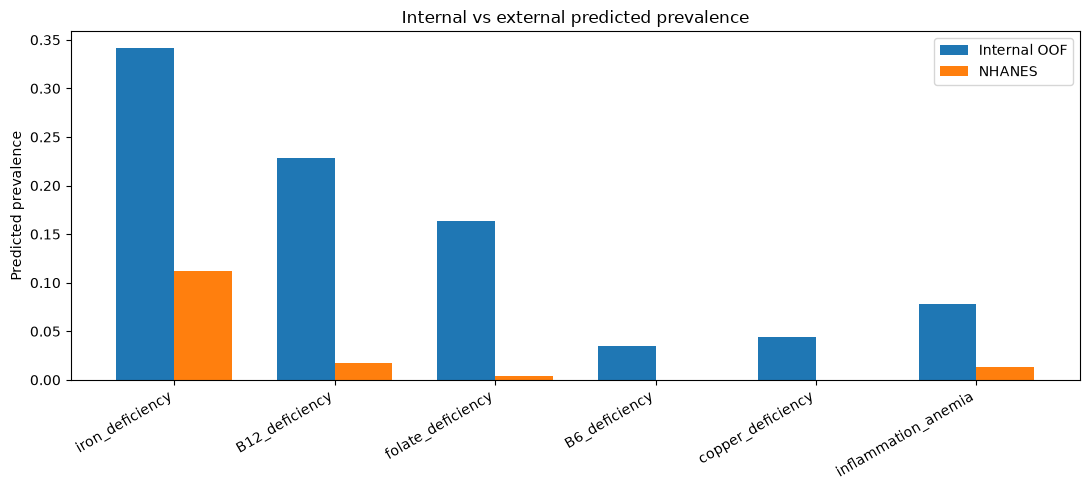

In [63]:
plot_df = prediction_prevalence.copy()

targets = plot_df["target"].tolist()
x = np.arange(len(targets))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    x - width / 2,
    plot_df["internal_oof_predicted_prevalence"],
    width,
    label="Internal OOF",
)

ax.bar(
    x + width / 2,
    plot_df["external_all_predicted_prevalence"],
    width,
    label="NHANES",
)

ax.set_xticks(x)
ax.set_xticklabels(targets, rotation=30, ha="right")
ax.set_ylabel("Predicted prevalence")
ax.set_title("Internal vs external predicted prevalence")
ax.legend()

plt.tight_layout()
plt.show()


### Интерпретация

Большое изменение predicted prevalence не является автоматически ошибкой модели.

В нашем случае внешняя выборка:
- популяционная;
- моложе;
- значительно менее насыщена пациентами с анемией/дефицитами;
- имеет другой pattern пропусков;
- не содержит части ключевых лабораторных показателей.

Поэтому различия в prevalence рассматриваем как **domain-shift signal**, а не как внешний performance metric.


## 7. Missingness shift

In [64]:
display(missingness_shift.head(15))


,feature,internal_missing_pct,external_missing_pct,missingness_shift_pp
0,eGFR,35.595238,100.000000,64.404762
1,UIBC,35.714286,100.000000,64.285714
2,TIBC,35.714286,100.000000,64.285714
3,TSAT,35.714286,100.000000,64.285714
4,transferrin,35.714286,100.000000,64.285714
5,vitamin_B12,38.928571,100.000000,61.071429
6,ESR,41.428571,100.000000,58.571429
7,ferritin,29.285714,83.658761,54.373047
8,TSH,49.404762,100.000000,50.595238
9,reticulocytes,52.261905,100.000000,47.738095


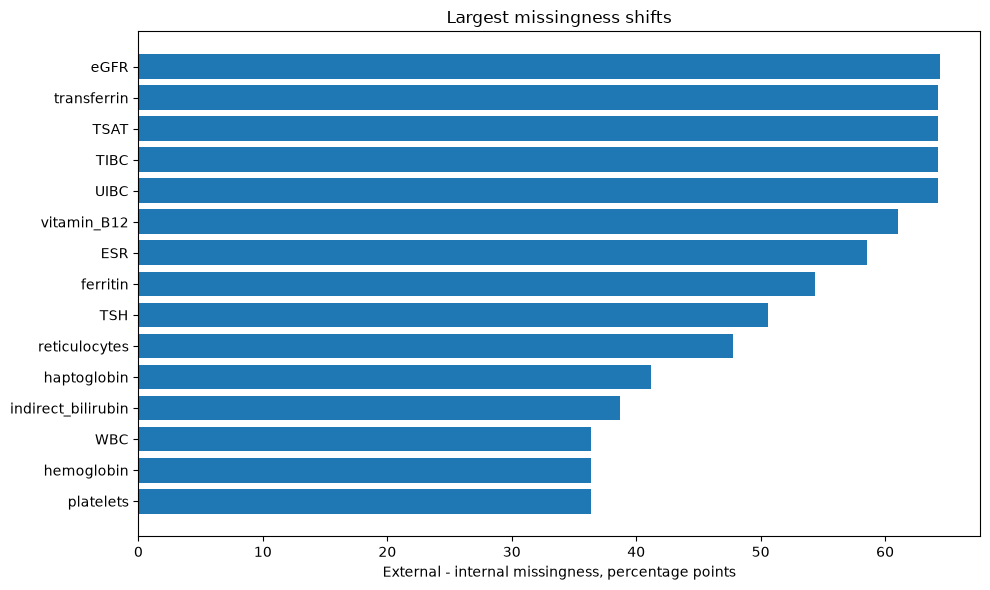

In [65]:
top_missing = missingness_shift.head(15).sort_values(
    "missingness_shift_pp"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_missing["feature"],
    top_missing["missingness_shift_pp"],
)

ax.set_xlabel("External - internal missingness, percentage points")
ax.set_title("Largest missingness shifts")

plt.tight_layout()
plt.show()


### Интерпретация

Это один из главных результатов NHANES stress-test.

Если ключевой feature отсутствует у 100% внешних пациентов,
модель вынуждена работать далеко от исходного training distribution.

Поэтому высокую numerical confidence нельзя автоматически трактовать как высокую clinical confidence.


## 8. Distribution shift

In [66]:
display(distribution_shift)


,feature,internal_n,external_n,internal_median,external_median,median_shift_in_internal_IQR,ks_statistic,ks_pvalue
0,LDH,325,4740,237.000,160.00,-0.675439,0.604778,2.328844e-106
1,MCHC,840,7593,322.600,338.00,0.916667,0.554311,2.727034e-217
2,sTfR,252,1949,1.915,3.16,0.618634,0.531895,5.432288e-59
3,hemoglobin,840,7593,111.700,137.00,0.681023,0.508269,1.843902e-180
4,folate,455,7348,6.000,15.00,1.132075,0.479892,5.927865e-91
5,RDW,825,7593,15.500,13.50,-0.512821,0.466670,2.817422e-148
6,RBC,840,7593,4.000,4.66,0.510638,0.445355,1.233183e-136
7,hematocrit,840,7593,35.100,40.60,0.543210,0.433941,1.946476e-129
8,age_years,840,11933,60.000,37.00,-0.766667,0.353596,2.677671e-88
9,serum_iron,540,6364,11.650,15.00,0.310185,0.271451,7.414403e-33


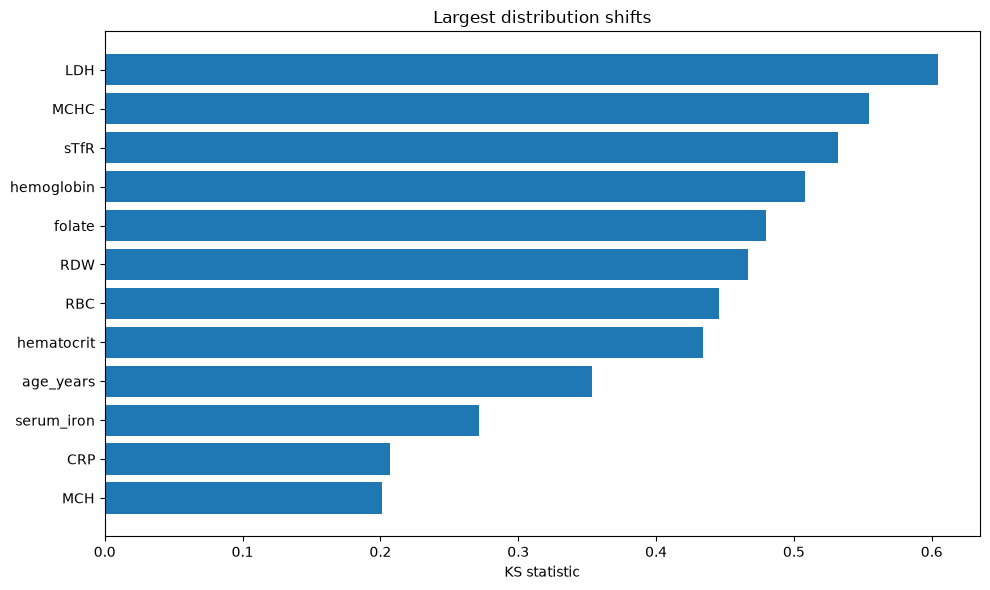

In [67]:
top_shift = distribution_shift.head(12).sort_values(
    "ks_statistic"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_shift["feature"],
    top_shift["ks_statistic"],
)

ax.set_xlabel("KS statistic")
ax.set_title("Largest distribution shifts")

plt.tight_layout()
plt.show()


### Интерпретация

KS statistic измеряет различие распределений между внутренним и внешним датасетами.

- значение около 0 — распределения похожи;
- большое значение — сильный shift.

Здесь мы используем KS не как clinical metric, а как инструмент обнаружения transfer risk.


## 9. L1 vs CatBoost disagreement

In [68]:
display(model_disagreement)


,target,median_abs_l1_cat_diff,q75_abs_l1_cat_diff,q90_abs_l1_cat_diff,max_abs_l1_cat_diff
0,iron_deficiency,0.014047,0.033646,0.081505,0.993646
1,B12_deficiency,0.008721,0.015949,0.076041,0.997733
2,folate_deficiency,0.005110,0.023915,0.024344,0.535315
3,B6_deficiency,0.007604,0.049453,0.054978,0.342628
4,copper_deficiency,0.001888,0.014279,0.017747,0.017747
5,inflammation_anemia,0.000520,0.001312,0.002672,0.999843


### Интерпретация

Если две архитектурно разные модели на внешнем датасете в основном дают близкие вероятности,
это дополнительный сигнал технической устойчивости.

Но отдельные случаи с большим disagreement нужно трактовать как candidates for review / uncertainty flag.


## 10. Distance from decision thresholds

In [69]:
display(threshold_margin)


,target,threshold,median_abs_margin,pct_within_0_05_of_threshold,pct_within_0_10_of_threshold
0,iron_deficiency,0.41,0.388676,0.796112,1.433001
1,B12_deficiency,0.26,0.254818,1.156457,2.321294
2,folate_deficiency,0.45,0.446961,0.100561,0.259784
3,B6_deficiency,0.45,0.437088,0.000000,0.000000
4,copper_deficiency,0.18,0.178453,0.000000,0.000000
5,inflammation_anemia,0.38,0.379766,0.460907,0.879913


### Интерпретация

Этот анализ показывает, насколько часто external probability находится близко к frozen threshold.

Он **не является медицинской confidence score**.

Даже очень большое расстояние от threshold не гарантирует клиническую надёжность,
если у пациента отсутствует значительная часть ключевых анализов.


## 11. Финальная классификация результата NHANES

### Что NHANES нам реально дал

**1. Техническую external validation pipeline**
- модель принимает независимые данные;
- feature contract работает;
- preprocessing и frozen inference воспроизводимы;
- модели и thresholds не настраивались по NHANES.

**2. Stress-test при missing features**
- показано, что внешний источник содержит только часть исходного feature space;
- измерена patient-level coverage;
- выявлены признаки, которые отсутствуют полностью.

**3. Domain-shift analysis**
- показано отличие возрастной структуры;
- показано отличие распределений лабораторных признаков;
- показано изменение predicted prevalence;
- измерено disagreement двух моделей.

### Что NHANES нам НЕ дал

NHANES не дал полноценной внешней проверки:
- 12-class Macro-F1;
- 12-class Accuracy;
- Macro Recall;
- confusion matrix;
- calibration against true labels;
- sensitivity/specificity для всех 6 дефицитов.

Причина — отсутствие сопоставимого independent ground truth и неполное совпадение лабораторных признаков.


## 12. Формулировка для презентации / защиты

Можно использовать такую формулировку:

> После фиксации архитектуры мы провели внешний transfer test на независимых публичных данных NHANES. Модель не переобучалась и не настраивалась на внешней выборке. Мы сопоставили лабораторные признаки с frozen 37-feature contract, оценили feature coverage, missingness shift, distribution shift и устойчивость предсказаний ансамбля L1 + CatBoost. NHANES содержит только часть необходимых лабораторных показателей и не предоставляет сопоставимый ground truth для всех шести дефицитов и 12 итоговых классов, поэтому мы сознательно не сообщаем искусственный external Macro-F1. Вместо этого используем NHANES как внешний stress-test переносимости и инструмент оценки domain shift.

Более короткая версия для слайда:

> **External transfer test:** frozen L1 + CatBoost ensemble was evaluated on independent NHANES data without retraining. We quantified feature coverage, missingness and distribution shift, and model disagreement. Full external 12-class accuracy was not reported because NHANES lacks comparable ground truth for the complete task.


## 13. Что считать основным результатом модели

Для оценки качества алгоритма продолжаем использовать **внутренний OOF evaluation**,
потому что именно там есть корректный ground truth для всех классов.

Основной результат из frozen internal evaluation:

- Macro-F1 ≈ **0.900**
- Balanced Accuracy ≈ **0.886**
- Accuracy ≈ **0.905**

NHANES не заменяет эти метрики — он отвечает на другой вопрос:

> Что произойдёт, если уже обученную систему без адаптации перенести на независимый источник данных с другим набором лабораторных исследований?


## 14. Итоговый статус notebook 06

После выполнения Part 5:

**06_external_validation можно считать завершённым.**

Что зафиксировано:

- frozen inference bundle создан;
- внешние данные подключены;
- mapping и units проверены;
- feature coverage рассчитан;
- external inference выполнен без training;
- missingness shift рассчитан;
- distribution shift рассчитан;
- model disagreement рассчитан;
- ограничения external validation формально описаны.

Следующий исследовательский notebook:

# `07_expert_system.ipynb`

В нём:
- формализуем expert knowledge;
- отделяем `unknown` от `negative`;
- создаём facts → rules → fired rules;
- подключаем ML probabilities;
- обрабатываем conflicts;
- формируем recommended next tests;
- готовим physician-facing explanation.

После `07` новые исследовательские notebooks не создаём:
рабочую логику переносим в `ml/`, `expert/` и API.


## 15. Сохраняем итоговые summary tables


In [70]:
summary_path = EXTERNAL_DIR / "external_validation_summary.csv"
scope_path = EXTERNAL_DIR / "external_validation_claims.csv"

summary.to_csv(summary_path, index=False)
validation_scope.to_csv(scope_path, index=False)

print("Saved:", summary_path)
print("Saved:", scope_path)
print("\nPART 5 COMPLETE")
print("06_external_validation = COMPLETE")


Saved: /home/sinopah/meditron/artifacts/external_validation/external_validation_summary.csv
Saved: /home/sinopah/meditron/artifacts/external_validation/external_validation_claims.csv

PART 5 COMPLETE
06_external_validation = COMPLETE
